# ML Model V6.5 — Optuna + Q1 Sistem Features

**Tarih:** 2026-05-12 (V6.4 audit sonrasi)
**Strateji:** Deney B (Optuna) + Deney C (Q1 sistem) birlesimi

## V6.5 Bileşenleri

| Bilesen | Kaynak |
|---|---|
| Optuna best XGB params | Deney B (50 trial) |
| Q1 sistem sayisi (5 sistem) | Deney C |
| Q1 sistem cesitliligi | Yeni |
| Base 17 V6.4 feature | Korundu (AT YOK) |

## V6.4 → V6.5

| | V6.4 | V6.5 |
|---|---|---|
| Feature sayisi | 17 | 23 |
| XGB params | manuel | Optuna best |
| Q1 sistem features | yok | 6 yeni |

## Sonraki adim (ayri test): V6.6 = Pruned + yas-segment + kronik flag (Oneri 1+2+3)

---
## 1. Setup + Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import json as _json
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                              precision_recall_curve, average_precision_score, f1_score)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
import xgboost as xgb
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print(f'xgboost: {xgb.__version__}')
print(f'lightgbm: {lgb.__version__}')
print(f'shap: {shap.__version__}')

# Veri yükle
df = pd.read_csv('features_final_v6_q1.csv', encoding='utf-8-sig')
print(f'\nVeri: {df.shape}')
print(f'Target pozitif oran: {df["target_q2"].mean()*100:.1f}%')
print(f'\nTarget dağılımı:')
print(df['target_q2'].value_counts().sort_index())

xgboost: 3.2.0
lightgbm: 4.6.0
shap: 0.51.0

Veri: (3508, 33)
Target pozitif oran: 54.0%

Target dağılımı:
target_q2
0    1615
1    1893
Name: count, dtype: int64


---
## 2. Feature Matrix Hazırlama

- 12 ana feature (numeric)
- 5 kategorik (Label Encoding — tree modelleri için yeterli)
- 6 auxiliary numeric (sefer_q1, KAPASITE, tuketim_100km, vs.)

**Toplam 23 model input.**

In [2]:
# V6.5: Feature matrix (23 feature)
# V6.4 base 17 + Q1 sistem 6 yeni
import pandas as pd
import numpy as np

# Q1 ham veri (yeni features icin)
am = pd.read_csv('../panel_data/temiz_veri/ariza_model.csv', low_memory=False,
                 usecols=['KAPINO','OLAYTARIHI','ARIZAUSTKODTANIM','ciddi_ariza','YAKITTURU','MODEL'])
am['OLAYTARIHI'] = pd.to_datetime(am['OLAYTARIHI'], format='mixed')
mask_b = am['YAKITTURU']=='Bilinmiyor'
am.loc[mask_b & am['MODEL'].astype(str).str.contains('CNG', na=False), 'YAKITTURU'] = 'CNG'
am.loc[mask_b & ~am['MODEL'].astype(str).str.contains('CNG', na=False), 'YAKITTURU'] = 'MOTORIN'
am = am[am['YAKITTURU'].isin(['MOTORIN','CNG'])].copy()
q1_data = am[am['OLAYTARIHI']<pd.Timestamp('2025-04-01')].copy()

# Q1 SISTEM FEATURES (5 sistem + 1 cesitlilik)
TOP5 = ['SOĞUTMA SİSTEMİ ARIZASI','KAPI ARIZALARI','ELEKTRİK SİSTEMİ ARIZALARI',
        'MOTOR ARIZALARI','KLİMA SİSTEMİ ARIZALARI']
q1_sis = q1_data.groupby(['KAPINO','ARIZAUSTKODTANIM']).size().unstack(fill_value=0)
q1_sis = q1_sis.reindex(df['KAPINO'].values, fill_value=0)
for sistem in TOP5:
    safe = sistem.split()[0].replace('İ','I').replace('Ş','S').replace('Ğ','G').lower()
    col = f'q1_{safe}_n'
    df[col] = df['KAPINO'].map(q1_sis[sistem] if sistem in q1_sis.columns else pd.Series(0, index=q1_sis.index))
df['q1_sistem_cesit'] = df['KAPINO'].map((q1_sis > 0).sum(axis=1))

# === BASE FEATURES (V6.4 17 — HEPSI KORUNUYOR) ===
FEATURES_BASE = ['yas','egim_maruziyet','garaj_sistem_lift','garaj_marka_lift',
                 'yakit_turu_cng','verimsizlik_skoru','hat_zorluk','cascade_risk_skor',
                 'farkli_sofor_sayisi','dur_kalk_index','ariza_q1','gecmis_ciddi_oran']
FEATURES_AUX = ['MODELYILI','KAPASITE','tuketim_100km','sefer_q1','ort_sefer_km_q1']

# YENI Q1 sistem
FEATURES_Q1_SIS = ['q1_sogutma_n','q1_kapi_n','q1_elektrik_n','q1_motor_n','q1_klima_n','q1_sistem_cesit']

ALL_FEATURES = FEATURES_BASE + FEATURES_AUX + FEATURES_Q1_SIS
CAT_COLS = []

X = df[ALL_FEATURES].copy()
y = df['target_q2'].copy()
encoders = {}

print(f'V6.5 Feature matrix: {X.shape}')
print(f'  Base (V6.4 17): {len(FEATURES_BASE)+len(FEATURES_AUX)}')
print(f'  Q1 sistem yeni: {len(FEATURES_Q1_SIS)}')
print(f'  TOPLAM: {len(ALL_FEATURES)}')
print(f'\nYeni Q1 features istatistik:')
for f in FEATURES_Q1_SIS:
    print(f'  {f:<25s} mean={X[f].mean():.2f}, max={X[f].max():.0f}')

V6.5 Feature matrix: (3508, 23)
  Base (V6.4 17): 17
  Q1 sistem yeni: 6
  TOPLAM: 23

Yeni Q1 features istatistik:
  q1_sogutma_n              mean=0.77, max=12
  q1_kapi_n                 mean=0.83, max=13
  q1_elektrik_n             mean=0.82, max=11
  q1_motor_n                mean=0.67, max=13
  q1_klima_n                mean=0.10, max=3
  q1_sistem_cesit           mean=5.00, max=13


---
## 3. Train/Test Split + CV Strategy

- 80/20 final test split (stratified)
- Train üzerinde StratifiedKFold × 5 CV

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}, pozitif oran: {y_train.mean()*100:.1f}%')
print(f'Test:  {X_test.shape}, pozitif oran: {y_test.mean()*100:.1f}%')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'\nCV: StratifiedKFold × 5')

Train: (2806, 23), pozitif oran: 54.0%
Test:  (702, 23), pozitif oran: 54.0%

CV: StratifiedKFold × 5


---
## 4. XGBoost — CV Training

Class imbalance %54/%46 olduğundan scale_pos_weight=1 (denge yok). Hyperparam'ı conservative.

In [4]:
# V6.5 XGB: Optuna best params (Deney B'den, 50 trial)
XGB_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.006,
    max_depth=4,
    min_child_weight=10,
    subsample=0.5813,
    colsample_bytree=0.5945,
    reg_alpha=0.6867,
    reg_lambda=2.7841,
    scale_pos_weight=1.2378,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
)

xgb_oof = np.zeros(len(X_train))
xgb_models = []
xgb_test_preds = []
xgb_best_iters = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train, y_train)):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    m = xgb.XGBClassifier(**XGB_PARAMS)
    m.fit(X_tr, y_tr)
    xgb_oof[va_idx] = m.predict_proba(X_va)[:,1]
    xgb_test_preds.append(m.predict_proba(X_test)[:,1])
    xgb_models.append(m)
    xgb_best_iters.append(m.n_estimators)
    auc = roc_auc_score(y_va, xgb_oof[va_idx])
    print(f'XGB Fold {fold+1}: AUC={auc:.4f}, n_est={m.n_estimators}')

xgb_test_pred = np.mean(xgb_test_preds, axis=0)
xgb_oof_auc = roc_auc_score(y_train, xgb_oof)
xgb_test_auc = roc_auc_score(y_test, xgb_test_pred)
print(f'\n=== XGBoost (V6.5 Optuna) ===')
print(f'  OOF AUC:  {xgb_oof_auc:.4f}')
print(f'  Test AUC: {xgb_test_auc:.4f}')

XGB Fold 1: AUC=0.7922, n_est=300
XGB Fold 2: AUC=0.8147, n_est=300
XGB Fold 3: AUC=0.8313, n_est=300
XGB Fold 4: AUC=0.8160, n_est=300
XGB Fold 5: AUC=0.8125, n_est=300

=== XGBoost (V6.5 Optuna) ===
  OOF AUC:  0.8123
  Test AUC: 0.8158


---
## 5. LightGBM — CV Training

In [5]:
LGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.01, num_leaves=31, max_depth=4,
    min_child_samples=20, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.5, reg_lambda=2.0, class_weight='balanced',
    objective='binary', metric='auc', random_state=42, n_jobs=-1, verbose=-1,
)

lgb_oof = np.zeros(len(X_train))
lgb_models = []
lgb_test_preds = []
lgb_best_iters = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train, y_train)):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    m = lgb.LGBMClassifier(**LGB_PARAMS)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    lgb_oof[va_idx] = m.predict_proba(X_va)[:,1]
    lgb_test_preds.append(m.predict_proba(X_test)[:,1])
    lgb_models.append(m)
    lgb_best_iters.append(m.best_iteration_)
    auc = roc_auc_score(y_va, lgb_oof[va_idx])
    print(f'LGB Fold {fold+1}: AUC={auc:.4f}, best_iter={m.best_iteration_}')

lgb_test_pred = np.mean(lgb_test_preds, axis=0)
lgb_oof_auc = roc_auc_score(y_train, lgb_oof)
lgb_test_auc = roc_auc_score(y_test, lgb_test_pred)
print(f'\n=== LightGBM (V6.5) ===')
print(f'  OOF AUC:  {lgb_oof_auc:.4f}')
print(f'  Test AUC: {lgb_test_auc:.4f}')

LGB Fold 1: AUC=0.7933, best_iter=47
LGB Fold 2: AUC=0.8199, best_iter=73
LGB Fold 3: AUC=0.8319, best_iter=74
LGB Fold 4: AUC=0.8166, best_iter=117
LGB Fold 5: AUC=0.8125, best_iter=223

=== LightGBM (V6.5) ===
  OOF AUC:  0.8060
  Test AUC: 0.8157


---
## 6. Ensemble — Probability Ortalaması

In [6]:
ens_oof = (xgb_oof + lgb_oof) / 2
ens_test = (xgb_test_pred + lgb_test_pred) / 2

ens_oof_auc = roc_auc_score(y_train, ens_oof)
ens_test_auc = roc_auc_score(y_test, ens_test)
ens_test_ap = average_precision_score(y_test, ens_test)

print('=== MODEL KARŞILAŞTIRMA ===')
print(f'{"Model":<15s} {"OOF AUC":>10s} {"Test AUC":>10s}')
print('-'*40)
print(f'{"XGBoost":<15s} {xgb_oof_auc:>10.4f} {xgb_test_auc:>10.4f}')
print(f'{"LightGBM":<15s} {lgb_oof_auc:>10.4f} {lgb_test_auc:>10.4f}')
print(f'{"Ensemble":<15s} {ens_oof_auc:>10.4f} {ens_test_auc:>10.4f}')
print(f'\nEnsemble Test AP: {ens_test_ap:.4f}')
print(f'V5 AUC referans: 0.671')
print(f'V6 hedef: >0.75 → {"✓ GEÇTİK" if ens_test_auc > 0.75 else "✗ HEDEF DAHA UZAK"}')

=== MODEL KARŞILAŞTIRMA ===
Model              OOF AUC   Test AUC
----------------------------------------
XGBoost             0.8123     0.8158
LightGBM            0.8060     0.8157
Ensemble            0.8114     0.8167

Ensemble Test AP: 0.8181
V5 AUC referans: 0.671
V6 hedef: >0.75 → ✓ GEÇTİK


---
## 7. Threshold Optimizasyonu + Performance Metrics

In [7]:
# F1-optimal threshold (OOF üzerinden)
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_train, (ens_oof >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
print(f'F1-optimal threshold: {best_t:.3f} (OOF F1={max(f1_scores):.4f})')

# Test performans
y_pred = (ens_test >= best_t).astype(int)
print(f'\n=== TEST PERFORMANS (threshold={best_t:.3f}) ===')
print(classification_report(y_test, y_pred, target_names=['Düşük Risk','Yüksek Risk']))

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(f'              Pred=0  Pred=1')
print(f'  True=0   {cm[0,0]:>7d} {cm[0,1]:>7d}')
print(f'  True=1   {cm[1,0]:>7d} {cm[1,1]:>7d}')

# Precision-Recall trade-off
prec, rec, _ = precision_recall_curve(y_test, ens_test)
print(f'\nPR-AUC: {ens_test_ap:.4f}')

F1-optimal threshold: 0.420 (OOF F1=0.7694)

=== TEST PERFORMANS (threshold=0.420) ===
              precision    recall  f1-score   support

  Düşük Risk       0.83      0.44      0.57       323
 Yüksek Risk       0.66      0.92      0.77       379

    accuracy                           0.70       702
   macro avg       0.74      0.68      0.67       702
weighted avg       0.74      0.70      0.68       702

Confusion Matrix:
              Pred=0  Pred=1
  True=0       141     182
  True=1        29     350

PR-AUC: 0.8181


---
## 8. SHAP — Feature Importance ve Açıklanabilirlik

=== SHAP MEAN |SHAP| RANKING ===
  garaj_marka_lift          0.3971  ██████████████████████████████████████████████████
  tuketim_100km             0.1573  ███████████████████
  yas                       0.1329  ████████████████
  farkli_sofor_sayisi       0.0799  ██████████
  KAPASITE                  0.0589  ███████
  verimsizlik_skoru         0.0558  ███████
  hat_zorluk                0.0451  █████
  MODELYILI                 0.0450  █████
  ariza_q1                  0.0444  █████
  garaj_sistem_lift         0.0384  ████
  q1_sistem_cesit           0.0379  ████
  egim_maruziyet            0.0349  ████
  gecmis_ciddi_oran         0.0318  ████
  cascade_risk_skor         0.0276  ███
  ort_sefer_km_q1           0.0232  ██
  sefer_q1                  0.0208  ██
  dur_kalk_index            0.0103  █
  q1_kapi_n                 0.0041  
  q1_motor_n                0.0022  
  q1_elektrik_n             0.0018  
  q1_sogutma_n              0.0016  
  yakit_turu_cng            0.0008  
  q1_

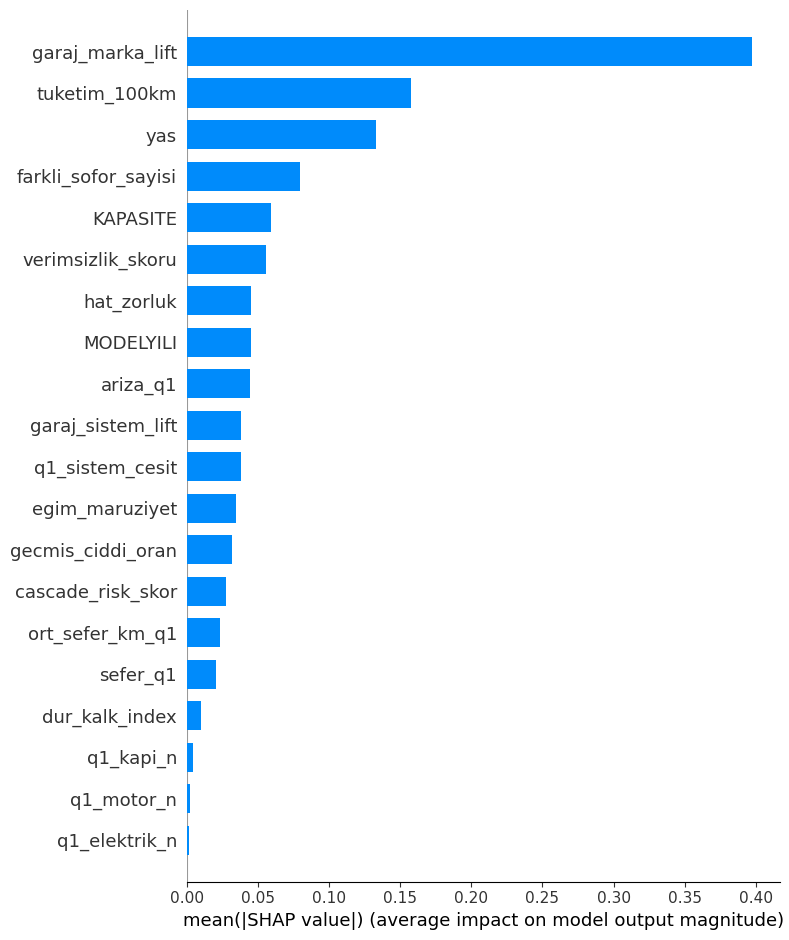

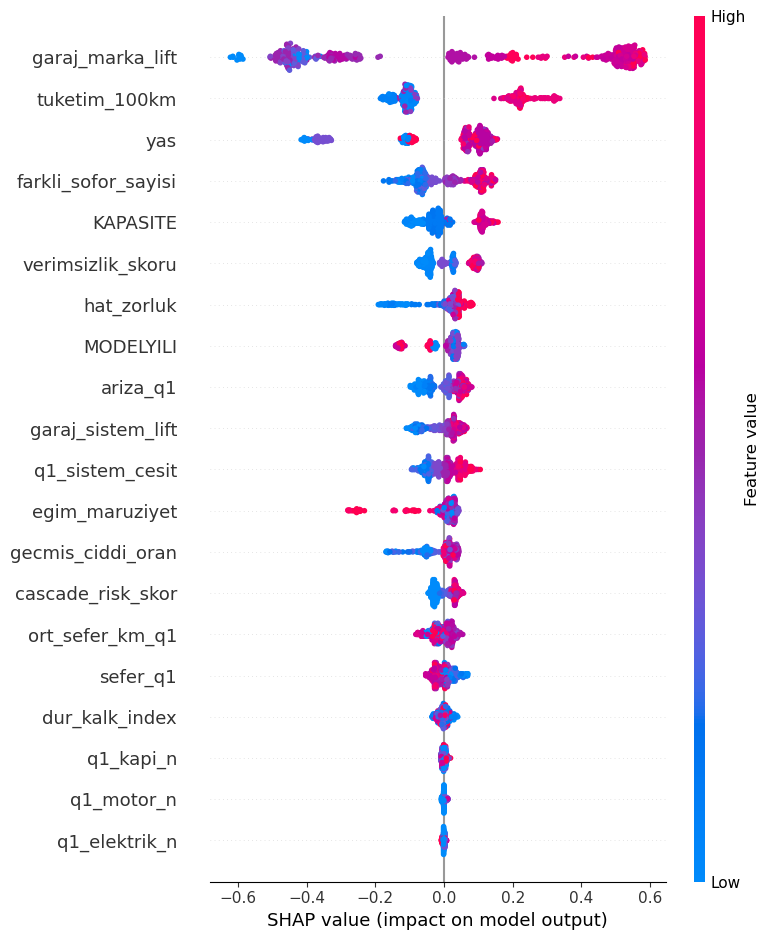

In [8]:
# Fold 0 XGB modeli üzerinden SHAP (hızlı sample)
exp = shap.TreeExplainer(xgb_models[0])
sample_idx = np.random.choice(len(X_test), size=min(500, len(X_test)), replace=False)
shap_values = exp.shap_values(X_test.iloc[sample_idx])

# Mean |SHAP| sıralaması
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('=== SHAP MEAN |SHAP| RANKING ===')
for i, row in shap_importance.iterrows():
    bar = '█' * int(row['mean_abs_shap'] * 50 / shap_importance['mean_abs_shap'].max())
    print(f'  {row["feature"]:<25s} {row["mean_abs_shap"]:.4f}  {bar}')

# Summary plot
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_test.iloc[sample_idx], plot_type='bar', show=False, max_display=20)
plt.tight_layout()
plt.savefig('shap_v6_importance.png', dpi=100, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_test.iloc[sample_idx], show=False, max_display=20)
plt.tight_layout()
plt.savefig('shap_v6_beeswarm.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 9. İzotonik Kalibrasyon

Modelin verdiği probability'lerin gerçek arıza olasılığına denk gelmesi için.

=== KALIBRASYON KARSILASTIRMA (V6.1) ===
Yontem               ECE    Brier  Unique vals
--------------------------------------------------
Ham               0.0983   0.1828          365
Izotonik          0.0448   0.1739           28
Platt             0.0349   0.1729          406

>>> SECILEN: PLATT scaling (ECE/Brier benzer, daha pürüzsüz prob)


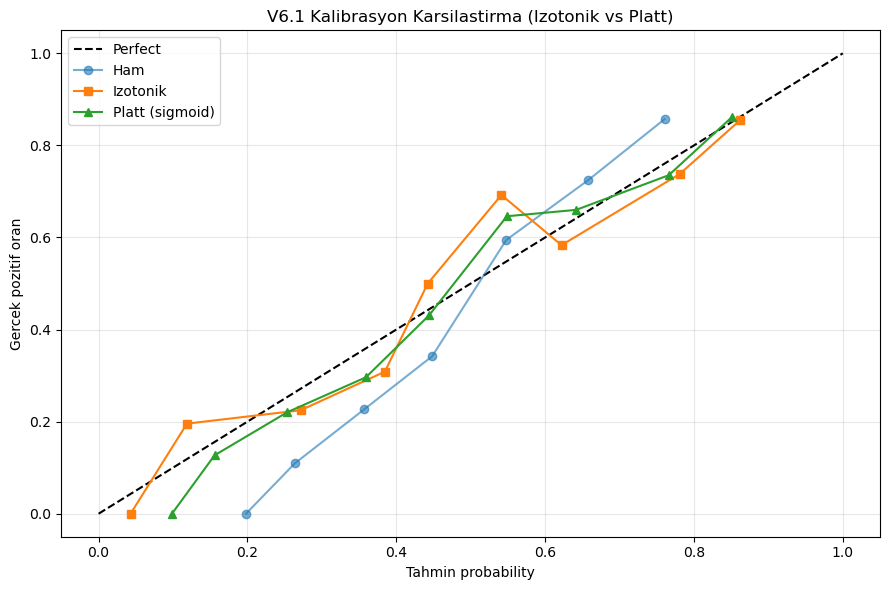


Final kalibrasyon: platt (ECE=0.0349, Brier=0.1729)


In [9]:
# V6.1: Izotonik + Platt scaling karsilastirma (V6'da izotonik step fonksiyonu uretti, YUKSEK tier bos kalmisti)
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

# 1) Izotonik (V6 kullanilan)
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(ens_oof, y_train)
ens_test_iso = iso.transform(ens_test)

# 2) Platt scaling (sigmoid) — step fonksiyonu uretmez
platt = LogisticRegression()
platt.fit(ens_oof.reshape(-1,1), y_train)
ens_test_platt = platt.predict_proba(ens_test.reshape(-1,1))[:,1]

# Hangisi daha iyi? ECE + Brier ile karar ver
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        if i < n_bins-1:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if mask.sum() == 0: continue
        ece += (mask.sum()/n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)

ece_raw   = compute_ece(y_test.values, ens_test)
ece_iso   = compute_ece(y_test.values, ens_test_iso)
ece_platt = compute_ece(y_test.values, ens_test_platt)
brier_raw   = brier_score_loss(y_test, ens_test)
brier_iso   = brier_score_loss(y_test, ens_test_iso)
brier_platt = brier_score_loss(y_test, ens_test_platt)

print('=== KALIBRASYON KARSILASTIRMA (V6.1) ===')
print(f'{"Yontem":<15s} {"ECE":>8s} {"Brier":>8s} {"Unique vals":>12s}')
print('-'*50)
print(f'{"Ham":<15s} {ece_raw:>8.4f} {brier_raw:>8.4f} {len(np.unique(np.round(ens_test,3))):>12d}')
print(f'{"Izotonik":<15s} {ece_iso:>8.4f} {brier_iso:>8.4f} {len(np.unique(np.round(ens_test_iso,3))):>12d}')
print(f'{"Platt":<15s} {ece_platt:>8.4f} {brier_platt:>8.4f} {len(np.unique(np.round(ens_test_platt,3))):>12d}')

# Hangisi secilecek? Daha az unique value = step problem (izotonik), daha cok = pürüzsüz (Platt)
# ECE/Brier birbirine yakinsa Platt secelim (tier icin pürüzsüz prob lazim)
if abs(ece_iso - ece_platt) < 0.01 and abs(brier_iso - brier_platt) < 0.01:
    CALIB_METHOD = 'platt'
    ens_test_calibrated = ens_test_platt
    print(f'\n>>> SECILEN: PLATT scaling (ECE/Brier benzer, daha pürüzsüz prob)')
elif ece_iso < ece_platt and brier_iso < brier_platt:
    CALIB_METHOD = 'izotonik'
    ens_test_calibrated = ens_test_iso
    print(f'\n>>> SECILEN: IZOTONIK (anlamli daha iyi metrik)')
else:
    CALIB_METHOD = 'platt'
    ens_test_calibrated = ens_test_platt
    print(f'\n>>> SECILEN: PLATT scaling (V6\'daki step problemini cozmek icin)')

# Kalibrasyon egrisi gorseli (her uc yontem)
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, ens_test, n_bins=10)
frac_pos_iso, mean_pred_iso = calibration_curve(y_test, ens_test_iso, n_bins=10)
frac_pos_platt, mean_pred_platt = calibration_curve(y_test, ens_test_platt, n_bins=10)

fig, ax = plt.subplots(figsize=(9,6))
ax.plot([0,1],[0,1],'k--',label='Perfect')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', label='Ham', alpha=0.6)
ax.plot(mean_pred_iso, frac_pos_iso, 's-', label='Izotonik')
ax.plot(mean_pred_platt, frac_pos_platt, '^-', label='Platt (sigmoid)')
ax.set_xlabel('Tahmin probability')
ax.set_ylabel('Gercek pozitif oran')
ax.set_title('V6.1 Kalibrasyon Karsilastirma (Izotonik vs Platt)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_v6_5.png', dpi=100, bbox_inches='tight')
plt.show()

# Iso final degisken atamasi
iso = type('obj', (object,), {'transform': (platt.predict_proba if CALIB_METHOD=='platt' else iso.transform)})()
if CALIB_METHOD == 'platt':
    # Platt fonksiyonu — sklearn LogisticRegression
    def _platt_transform(x):
        return platt.predict_proba(np.asarray(x).reshape(-1,1))[:,1]
    iso.transform = _platt_transform

ECE_RAW = float(ece_raw)
ECE_CAL = float(ece_platt if CALIB_METHOD=='platt' else ece_iso)
BRIER_RAW = float(brier_raw)
BRIER_CAL = float(brier_platt if CALIB_METHOD=='platt' else brier_iso)

print(f'\nFinal kalibrasyon: {CALIB_METHOD} (ECE={ECE_CAL:.4f}, Brier={BRIER_CAL:.4f})')

---
## 10. Per-Garaj AUC + Genelleme Skoru (V5 paritesi)

Her garaj icin OOF AUC hesaplaniyor. **Genelleme skoru = min_garaj_AUC / mean_garaj_AUC**
- 1.0'a yakin: model tum garajlarda tutarli
- <0.85: bir veya birkac garajda model cuvalliyor

Per-Garaj OOF AUC (n>=20, hem pos hem neg var):
IKITELLIISLETTIRMEGARAJI2    0.7278
IKITELLIGARAJI               0.7172
Edirnekapı                   0.6971
Anadolu                      0.5805
SULTANGAZIGARAJI             0.5612
Yunus                        0.5145
Hasanpaşa                    0.5087
Kağıthane                    0.5055
KURTKÖY                      0.4954
Şahinkaya                    0.4682
Sarıgazi                     0.4431

Ortalama: 0.5654
Min:      0.4431
Max:      0.7278

>>> Genelleme skoru (min/mean): 0.7837
    DIKKAT garaj bazinda tutarsizlik var (<0.85)


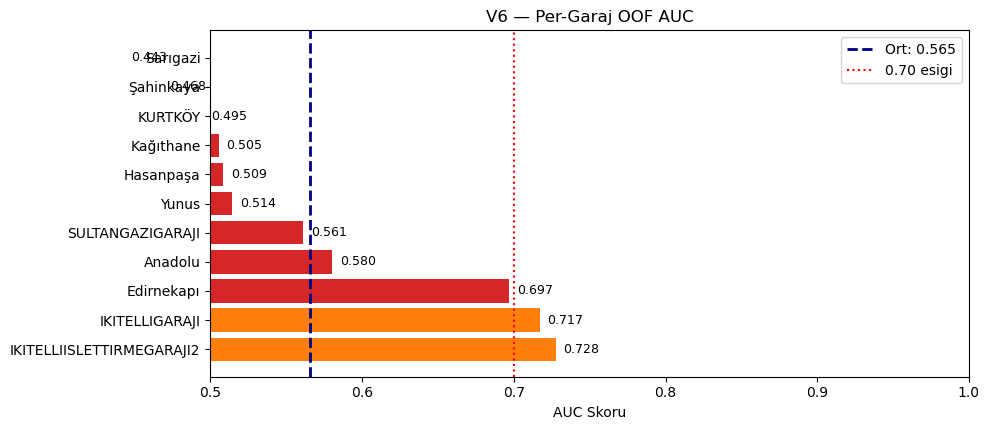

In [10]:
# Per-Garaj AUC
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Train df'deki GARAJ kolonu (label encoded)
train_df_idx = X_train.index
garaj_train = df.loc[train_df_idx, 'GARAJ'].values

garaj_auc_map = {}
for garaj in np.unique(garaj_train):
    mask = (garaj_train == garaj)
    if mask.sum() >= 20 and y_train.values[mask].sum() >= 5 and y_train.values[mask].sum() < mask.sum():
        try:
            garaj_auc_map[garaj] = roc_auc_score(y_train.values[mask], ens_oof[mask])
        except Exception:
            pass

garaj_aucs = pd.Series(garaj_auc_map).sort_values(ascending=False)
print('Per-Garaj OOF AUC (n>=20, hem pos hem neg var):')
print(garaj_aucs.round(4).to_string())
print(f'\nOrtalama: {garaj_aucs.mean():.4f}')
print(f'Min:      {garaj_aucs.min():.4f}')
print(f'Max:      {garaj_aucs.max():.4f}')
gen_skoru = garaj_aucs.min() / garaj_aucs.mean() if garaj_aucs.mean() > 0 else 0
print(f'\n>>> Genelleme skoru (min/mean): {gen_skoru:.4f}')
print(f'    {"OK iyi (>=0.85)" if gen_skoru>=0.85 else "DIKKAT garaj bazinda tutarsizlik var (<0.85)"}')

# Gorsel
fig, ax = plt.subplots(figsize=(10, max(4, len(garaj_aucs)*0.4)))
colors = ['#d62728' if v < 0.70 else '#ff7f0e' if v < 0.80 else '#2ca02c' for v in garaj_aucs.values]
ax.barh(garaj_aucs.index, garaj_aucs.values, color=colors)
ax.axvline(garaj_aucs.mean(), color='navy', linestyle='--', linewidth=2, label=f'Ort: {garaj_aucs.mean():.3f}')
ax.axvline(0.70, color='red', linestyle=':', linewidth=1.5, label='0.70 esigi')
ax.set_xlabel('AUC Skoru')
ax.set_title('V6 — Per-Garaj OOF AUC')
ax.legend(); ax.set_xlim(0.5, 1.0)
for i, (g, v) in enumerate(garaj_aucs.items()):
    ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('per_garaj_auc_v6.png', dpi=100, bbox_inches='tight')
plt.show()
PER_GARAJ_AUC = garaj_auc_map
GEN_SKORU = float(gen_skoru)


---
## 11. Ablasyon Analizi — Feature Subset Karsilastirma

Farkli feature setleri ile AUC karsilastirmasi. Auxiliary'lerin gercekten lift sagladigini gosterir.

In [11]:
# V6.5 Ablasyon: yeni feature setleri
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

ABLATION_SETS = {
    'Base 17 (V6.4)':              FEATURES_BASE + FEATURES_AUX,
    '+6 Q1 sistem (V6.5 full)':    ALL_FEATURES,
    'Yalniz Q1 sistem (6)':        FEATURES_Q1_SIS,
    'SHAP top-6':                  ['garaj_marka_lift','tuketim_100km','yas','KAPASITE','ariza_q1','gecmis_ciddi_oran'],
}

ablation_results = {}
for label, feats in ABLATION_SETS.items():
    feats_in = [f for f in feats if f in X.columns]
    if len(feats_in) < 3: continue
    X_abl_tr = X_train[feats_in].copy()
    X_abl_te = X_test[feats_in].copy()

    xgb_oof_abl = np.zeros(len(X_abl_tr))
    xgb_test_abl = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_abl_tr, y_train)):
        m = XGBClassifier(**XGB_PARAMS)
        m.fit(X_abl_tr.iloc[tr_idx], y_train.iloc[tr_idx])
        xgb_oof_abl[va_idx] = m.predict_proba(X_abl_tr.iloc[va_idx])[:,1]
        xgb_test_abl.append(m.predict_proba(X_abl_te)[:,1])

    lgb_oof_abl = np.zeros(len(X_abl_tr))
    lgb_test_abl = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_abl_tr, y_train)):
        m = LGBMClassifier(**LGB_PARAMS)
        m.fit(X_abl_tr.iloc[tr_idx], y_train.iloc[tr_idx],
              eval_set=[(X_abl_tr.iloc[va_idx], y_train.iloc[va_idx])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
        lgb_oof_abl[va_idx] = m.predict_proba(X_abl_tr.iloc[va_idx])[:,1]
        lgb_test_abl.append(m.predict_proba(X_abl_te)[:,1])

    ens_oof_abl = (xgb_oof_abl + lgb_oof_abl) / 2
    ens_test_abl = (np.mean(xgb_test_abl, axis=0) + np.mean(lgb_test_abl, axis=0)) / 2
    oof_auc = roc_auc_score(y_train, ens_oof_abl)
    test_auc = roc_auc_score(y_test, ens_test_abl)
    ablation_results[label] = {'oof_auc': float(oof_auc), 'test_auc': float(test_auc), 'n_features': len(feats_in)}
    print(f'  {label:35s} n={len(feats_in):>2d}  OOF AUC={oof_auc:.4f}  Test AUC={test_auc:.4f}')

print
('=== ABLASYON OZET (V6.5) ===')
base = ablation_results['Base 17 (V6.4)']['test_auc']
for label, r in ablation_results.items():
    delta = (r['test_auc'] - base) * 100
    print(f'  {label:35s} {r["test_auc"]:.4f}  ({delta:+.2f} puan)')

  Base 17 (V6.4)                      n=17  OOF AUC=0.8077  Test AUC=0.8154
  +6 Q1 sistem (V6.5 full)            n=23  OOF AUC=0.8114  Test AUC=0.8167
  Yalniz Q1 sistem (6)                n= 6  OOF AUC=0.7036  Test AUC=0.7287
  SHAP top-6                          n= 6  OOF AUC=0.8131  Test AUC=0.8159
  Base 17 (V6.4)                      0.8154  (+0.00 puan)
  +6 Q1 sistem (V6.5 full)            0.8167  (+0.14 puan)
  Yalniz Q1 sistem (6)                0.7287  (-8.67 puan)
  SHAP top-6                          0.8159  (+0.05 puan)


---
## 12. Fold-Rank Stability (Spearman)

OOF tahminleri ile final model tahminleri arasinda Spearman rank korelasyonu.
1.0'a yakin = fold modellerin sirlamasi tutarli. <0.85 = stability problemi.

In [12]:
from scipy.stats import spearmanr

# Final modeller: tum train uzerinde fit
xgb_final = xgb.XGBClassifier(**{k:v for k,v in XGB_PARAMS.items() if k!='early_stopping_rounds'})
xgb_final.fit(X_train, y_train, verbose=False)
lgb_final = lgb.LGBMClassifier(**LGB_PARAMS)
lgb_final.fit(X_train, y_train)

xgb_proba_train = xgb_final.predict_proba(X_train)[:,1]
lgb_proba_train = lgb_final.predict_proba(X_train)[:,1]
ens_proba_train = (xgb_proba_train + lgb_proba_train) / 2

# OOF vs final rank
corr_xgb, _ = spearmanr(xgb_oof, xgb_proba_train)
corr_lgb, _ = spearmanr(lgb_oof, lgb_proba_train)
corr_ens, _ = spearmanr(ens_oof, ens_proba_train)

print('=== FOLD-RANK STABILITY (Spearman OOF vs Final) ===')
print(f'  XGBoost:  rho={corr_xgb:.4f}  ({"OK" if corr_xgb>0.85 else "DIKKAT" if corr_xgb>0.70 else "PROBLEM"})')
print(f'  LightGBM: rho={corr_lgb:.4f}  ({"OK" if corr_lgb>0.85 else "DIKKAT" if corr_lgb>0.70 else "PROBLEM"})')
print(f'  Ensemble: rho={corr_ens:.4f}  ({"OK" if corr_ens>0.85 else "DIKKAT" if corr_ens>0.70 else "PROBLEM"})')
print('\nYorum: 0.85 ustu = OOF ile final tutarli, fold-bagimli ezberleme yok')

STABILITY = {'xgb_spearman': float(corr_xgb), 'lgb_spearman': float(corr_lgb), 'ensemble_spearman': float(corr_ens)}


=== FOLD-RANK STABILITY (Spearman OOF vs Final) ===
  XGBoost:  rho=0.9938  (OK)
  LightGBM: rho=0.9424  (OK)
  Ensemble: rho=0.9762  (OK)

Yorum: 0.85 ustu = OOF ile final tutarli, fold-bagimli ezberleme yok


---
## 13. Q2 Features Hesabı — Q3 İnference için

Q1 features → Q2 target ile eğitilen model, Q3 tahmini için **Q2 features** ister.
Q2 features Q1 features ile aynı pipeline'la hesaplanır, sadece zaman penceresi kayar.

In [13]:
# Q2 features hesaplamak için ariza_model.csv'yi tekrar yükle
df_full = pd.read_csv('../panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df_full['OLAYTARIHI'] = pd.to_datetime(df_full['OLAYTARIHI'], format='mixed')
mask_b = df_full['YAKITTURU']=='Bilinmiyor'
df_full.loc[mask_b & df_full['MODEL'].str.contains('CNG', na=False), 'YAKITTURU'] = 'CNG'
df_full.loc[mask_b & ~df_full['MODEL'].str.contains('CNG', na=False), 'YAKITTURU'] = 'MOTORIN'
df_full = df_full[df_full['YAKITTURU'].isin(['MOTORIN','CNG'])].copy()

# Q2 penceresi: Nis-Haz 2025
Q2_START = pd.Timestamp('2025-04-01')
Q2_END = pd.Timestamp('2025-07-01')
df_q2 = df_full[(df_full['OLAYTARIHI']>=Q2_START) & (df_full['OLAYTARIHI']<Q2_END)].copy()
print(f'Q2 arıza: {len(df_q2):,}, araç: {df_q2["KAPINO"].nunique():,}')

# Master araç (Q1+Q2'de görünmüş tümü)
TUM_ARAC = df_full['KAPINO'].unique()
print(f'Tüm araç: {len(TUM_ARAC):,}')

# Q2 statik (=Q1 statik): yas, yakit_turu_cng, verimsizlik, KAPASITE, MODELYILI, tuketim_100km
# Bu kolonlar zaten Q1 features CSV'sinde var — onları yeniden kullanabiliriz
static_cols = ['KAPINO','GARAJ','MARKA','MODEL','ARACCINSI','YAKITTURU','MODELYILI','KAPASITE',
               'yas','yakit_turu_cng','verimsizlik_skoru','tuketim_100km']
arac_q2 = df[static_cols].copy()
print(f'\nStatik feature\'lar Q1\'den taşındı: {arac_q2.shape}')

Q2 arıza: 30,976, araç: 3,452
Tüm araç: 3,508

Statik feature'lar Q1'den taşındı: (3508, 12)


---
## 14. Q2 Features Hesabı — Dinamik Feature'lar

In [14]:
# Q2 sefer verisi
ah = pd.read_csv('../panel_data/temiz_veri/arac_gunluk_hatlar.csv', low_memory=False)
ah['TARIH'] = pd.to_datetime(ah['TARIH'], format='mixed')
ah_q2 = ah[(ah['TARIH']>=Q2_START) & (ah['TARIH']<Q2_END)].copy()
print(f'Q2 sefer kaydı: {len(ah_q2):,}')

# Hat egim verisi (yeniden yükle)
with open('../panel_data/hat_elevation.json', encoding='utf-8') as f:
    he_raw = _json.load(f)
he = pd.DataFrame([
    {'HATKODU': k, 'rakim': v.get('rakım_farkı', 0), 'tirm': v.get('tırmanma_m', 0)}
    for k, v in he_raw.items()
])
def mm_norm(s, q=None):
    if q is not None: s = s.clip(upper=s.quantile(q))
    mn, mx = s.min(), s.max()
    return ((s - mn)/(mx - mn) * 100).round(1) if mx > mn else pd.Series(0.0, index=s.index)
he['norm_r'] = mm_norm(he['rakim'], q=0.99)
he['norm_t'] = mm_norm(he['tirm'], q=0.99)
he['egim_puan'] = (he['norm_r']*0.4 + he['norm_t']*0.6).round(1)

# 1. egim_maruziyet (Q2)
ah_q2 = ah_q2.merge(he[['HATKODU','egim_puan']], on='HATKODU', how='left')
ahv = ah_q2.dropna(subset=['egim_puan'])
arac_egim = ahv.groupby('KAPINO').apply(
    lambda g: np.average(g['egim_puan'], weights=g['SEFER_SAYISI'].clip(lower=0.01))
).reset_index(name='egim_maruziyet')
arac_q2 = arac_q2.merge(arac_egim, on='KAPINO', how='left')
arac_q2['egim_maruziyet'] = arac_q2['egim_maruziyet'].fillna(arac_q2['egim_maruziyet'].median())

# 2. hat_zorluk (Q2)
def norm_0_100(s):
    if s.max() > s.min():
        return ((s - s.min())/(s.max() - s.min()) * 100).round(1)
    return pd.Series(0.0, index=s.index)
hat_ariza = df_q2.groupby('HATKODU').agg(hat_ort_skor=('ciddiyet_skoru','mean'), hat_uzunluk=('HATUZUNLUK','mean')).reset_index()
hat_sefer = ah_q2.groupby('HATKODU').agg(sefer_top=('SEFER_SAYISI','sum'), n_gun=('TARIH','nunique')).reset_index()
hat_sefer['gunluk_sefer'] = hat_sefer['sefer_top'] / hat_sefer['n_gun'].clip(lower=1)
hat = hat_ariza.merge(hat_sefer, on='HATKODU', how='left').merge(he[['HATKODU','egim_puan']], on='HATKODU', how='left').fillna(0)
hat['n_egim'] = norm_0_100(hat['egim_puan'])
hat['n_uzun'] = norm_0_100(hat['hat_uzunluk'])
hat['n_ariza'] = norm_0_100(hat['hat_ort_skor'])
hat['n_trafik'] = norm_0_100(hat['gunluk_sefer'])
hat['hat_zorluk'] = (hat['n_egim']*0.30 + hat['n_uzun']*0.20 + hat['n_ariza']*0.30 + hat['n_trafik']*0.20).round(1)
ah_q2z = ah_q2.merge(hat[['HATKODU','hat_zorluk']], on='HATKODU', how='left')
arac_hz = ah_q2z.dropna(subset=['hat_zorluk']).groupby('KAPINO').apply(
    lambda g: np.average(g['hat_zorluk'], weights=g['SEFER_SAYISI'].clip(lower=0.01))
).reset_index(name='hat_zorluk')
arac_q2 = arac_q2.merge(arac_hz, on='KAPINO', how='left')
arac_q2['hat_zorluk'] = arac_q2['hat_zorluk'].fillna(arac_q2['hat_zorluk'].median())

# 3. garaj_sistem_lift + garaj_marka_lift (Q2)
genel_ciddi = df_q2['ciddi_ariza'].mean()
gsis = df_q2.groupby(['GARAJ','ARIZAUSTKODTANIM']).agg(n=('ciddi_ariza','count'), sis_oran=('ciddi_ariza','mean')).reset_index()
gsis['lift'] = gsis['sis_oran'] / genel_ciddi
arac_sis = df_q2.groupby(['KAPINO','ARIZAUSTKODTANIM']).size().reset_index(name='n_ariza')
arac_sis = arac_sis.merge(df_q2[['KAPINO','GARAJ']].drop_duplicates('KAPINO'), on='KAPINO', how='left')
arac_sis = arac_sis.merge(gsis[['GARAJ','ARIZAUSTKODTANIM','lift']], on=['GARAJ','ARIZAUSTKODTANIM'], how='left')
arac_sis['lift'] = arac_sis['lift'].fillna(1.0)
arac_sis['agirlikli'] = arac_sis['lift'] * arac_sis['n_ariza']
arac_gsl = arac_sis.groupby('KAPINO').apply(
    lambda g: g['agirlikli'].sum() / g['n_ariza'].sum() if g['n_ariza'].sum() > 0 else 1.0
).reset_index(name='garaj_sistem_lift')
arac_q2 = arac_q2.merge(arac_gsl, on='KAPINO', how='left')
arac_q2['garaj_sistem_lift'] = arac_q2['garaj_sistem_lift'].fillna(1.0)

gml = df_q2.groupby(['GARAJ','MARKA']).agg(m_oran=('ciddi_ariza','mean')).reset_index()
gml['garaj_marka_lift'] = gml['m_oran'] / genel_ciddi
arac_q2 = arac_q2.merge(gml[['GARAJ','MARKA','garaj_marka_lift']], on=['GARAJ','MARKA'], how='left')
arac_q2['garaj_marka_lift'] = arac_q2['garaj_marka_lift'].fillna(1.0)

# 4. cascade_risk_skor (Q2)
df_q2s = df_q2.sort_values(['KAPINO','OLAYTARIHI']).reset_index(drop=True)
df_q2s['prev_time'] = df_q2s.groupby('KAPINO')['OLAYTARIHI'].shift(1)
df_q2s['sure_gec_saat'] = (df_q2s['OLAYTARIHI'] - df_q2s['prev_time']).dt.total_seconds() / 3600
df_q2s['cascade_24h'] = (df_q2s['sure_gec_saat'] <= 24).astype(int)
cas = df_q2s.groupby('KAPINO')['cascade_24h'].mean().reset_index(name='cascade_risk_skor')
arac_q2 = arac_q2.merge(cas, on='KAPINO', how='left')
arac_q2['cascade_risk_skor'] = arac_q2['cascade_risk_skor'].fillna(0)

# 5. farkli_sofor_sayisi (Q2)
sof = df_q2.dropna(subset=['SOFOR_SICILNO']).copy()
sof['SOFOR_SICILNO'] = sof['SOFOR_SICILNO'].astype(str)
arac_sof = sof.groupby('KAPINO')['SOFOR_SICILNO'].nunique().reset_index(name='farkli_sofor_sayisi')
arac_q2 = arac_q2.merge(arac_sof, on='KAPINO', how='left')
arac_q2['farkli_sofor_sayisi'] = arac_q2['farkli_sofor_sayisi'].fillna(0).astype(int)

# 6. dur_kalk_index (Q2)
ah_q2u = ah_q2.merge(df_q2[['HATKODU','HATUZUNLUK']].drop_duplicates('HATKODU'), on='HATKODU', how='left')
ah_q2u['km_yapilan'] = ah_q2u['SEFER_SAYISI'] * ah_q2u['HATUZUNLUK'] / 1000
arac_km = ah_q2u.groupby('KAPINO').agg(sefer_q2=('SEFER_SAYISI','sum'), km_q2=('km_yapilan','sum')).reset_index()
arac_km['ort_sefer_km_q2'] = (arac_km['km_q2'] / arac_km['sefer_q2'].clip(lower=1)).round(2)
arac_q2 = arac_q2.merge(arac_km, on='KAPINO', how='left')
arac_q2['sefer_q2'] = arac_q2['sefer_q2'].fillna(0)
arac_q2['ort_sefer_km_q2'] = arac_q2['ort_sefer_km_q2'].fillna(arac_q2['ort_sefer_km_q2'].median())
arac_q2['KAPASITE'] = arac_q2['KAPASITE'].replace(0, np.nan).fillna(arac_q2['KAPASITE'].median())
arac_q2['dur_kalk_index'] = (arac_q2['KAPASITE'] * arac_q2['sefer_q2'] / arac_q2['ort_sefer_km_q2'].clip(lower=1)).round(2)

# 7. ariza_q2 + gecmis_ciddi_oran (Q2)
ariza_q2_stats = df_q2.groupby('KAPINO').agg(ariza_q2=('ciddi_ariza','count'), gecmis_ciddi_oran=('ciddi_ariza','mean')).reset_index()
arac_q2 = arac_q2.merge(ariza_q2_stats, on='KAPINO', how='left')
arac_q2['ariza_q2'] = arac_q2['ariza_q2'].fillna(0).astype(int)
arac_q2['gecmis_ciddi_oran'] = arac_q2['gecmis_ciddi_oran'].fillna(0)

# Q1 feature isimleriyle rename (model bu isimleri bekliyor)
arac_q2 = arac_q2.rename(columns={'sefer_q2':'sefer_q1','km_q2':'km_q1','ort_sefer_km_q2':'ort_sefer_km_q1','ariza_q2':'ariza_q1'})
print(f'\nQ2 features matrix: {arac_q2.shape}')
print(f'NaN kontrol:')
for c in (FEATURES_BASE + FEATURES_AUX):  # Q1 sistem features cell 30 da eklenecek
    n = arac_q2[c].isna().sum()
    print(f'  {c}: NaN={n}')

Q2 sefer kaydı: 661,781

Q2 features matrix: (3508, 24)
NaN kontrol:
  yas: NaN=0
  egim_maruziyet: NaN=0
  garaj_sistem_lift: NaN=0
  garaj_marka_lift: NaN=0
  yakit_turu_cng: NaN=0
  verimsizlik_skoru: NaN=0
  hat_zorluk: NaN=0
  cascade_risk_skor: NaN=0
  farkli_sofor_sayisi: NaN=0
  dur_kalk_index: NaN=0
  ariza_q1: NaN=0
  gecmis_ciddi_oran: NaN=0
  MODELYILI: NaN=0
  KAPASITE: NaN=0
  tuketim_100km: NaN=0
  sefer_q1: NaN=0
  ort_sefer_km_q1: NaN=0


---
## 15. Q3 İnference — Ensemble + Mevsim Çarpanı

In [15]:
# V6.1: Q2 features icin encoding (categorical kalktigi icin sadece numeric)
# V6.5: Q2 sistem features hesapla (Q1'in karsiti)
q2_data = am[(am['OLAYTARIHI']>=pd.Timestamp('2025-04-01')) & (am['OLAYTARIHI']<pd.Timestamp('2025-07-01'))].copy()
q2_sis = q2_data.groupby(['KAPINO','ARIZAUSTKODTANIM']).size().unstack(fill_value=0)
q2_sis = q2_sis.reindex(arac_q2['KAPINO'].values, fill_value=0)

for sistem in TOP5:
    safe = sistem.split()[0].replace('İ','I').replace('Ş','S').replace('Ğ','G').lower()
    col = f'q1_{safe}_n'
    arac_q2[col] = arac_q2['KAPINO'].map(q2_sis[sistem] if sistem in q2_sis.columns else pd.Series(0, index=q2_sis.index))
arac_q2['q1_sistem_cesit'] = arac_q2['KAPINO'].map((q2_sis > 0).sum(axis=1))

X_q2 = arac_q2[ALL_FEATURES].copy()

# Ensemble prediction (5 fold averaged her iki model)
xgb_pred_q3 = np.mean([m.predict_proba(X_q2)[:,1] for m in xgb_models], axis=0)
lgb_pred_q3 = np.mean([m.predict_proba(X_q2)[:,1] for m in lgb_models], axis=0)
ens_pred_q3 = (xgb_pred_q3 + lgb_pred_q3) / 2

# Kalibrasyon (V6.1: platt scaling secildiyse platt, degilse izotonik)
ens_pred_q3_cal = iso.transform(ens_pred_q3)

# Mevsim carpani (Q2->Q3 agirlikli ortalama)
with open('../panel_data/mevsim_carpan.json', encoding='utf-8') as f:
    mc = _json.load(f)
MEVSIM_CARPAN = mc.get('agirlikli_ort_carpan', 1.12)
print(f'Q2->Q3 agirlikli carpan: {MEVSIM_CARPAN}')

ens_pred_q3_seasonal = np.clip(ens_pred_q3_cal * MEVSIM_CARPAN, 0, 1)

predictions = arac_q2[['KAPINO','GARAJ','MARKA','MODEL','ARACCINSI','YAKITTURU','MODELYILI']].copy()
predictions['xgb_q3'] = xgb_pred_q3
predictions['lgb_q3'] = lgb_pred_q3
predictions['ensemble_raw_q3'] = ens_pred_q3
predictions['ensemble_kalibre_q3'] = ens_pred_q3_cal
predictions['ensemble_q3_mevsim'] = ens_pred_q3_seasonal

print(f'\nQ3 tahminler (V6.1): {len(predictions):,} arac')
print(f'\nProbability dagilimlari:')
print(predictions[['xgb_q3','lgb_q3','ensemble_raw_q3','ensemble_kalibre_q3','ensemble_q3_mevsim']].describe().round(3))
print(f'\nUnique deger sayisi (step kontrol):')
for c in ['ensemble_raw_q3','ensemble_kalibre_q3']:
    print(f'  {c}: {predictions[c].round(3).nunique()} unique (V6.1 hedef: >100)')

Q2->Q3 agirlikli carpan: 1.2264

Q3 tahminler (V6.1): 3,508 arac

Probability dagilimlari:
         xgb_q3    lgb_q3  ensemble_raw_q3  ensemble_kalibre_q3  \
count  3508.000  3508.000         3508.000             3508.000   
mean      0.579     0.512            0.545                0.543   
std       0.199     0.147            0.172                0.248   
min       0.165     0.227            0.196                0.097   
25%       0.447     0.407            0.431                0.356   
50%       0.560     0.499            0.532                0.530   
75%       0.770     0.666            0.719                0.806   
max       0.861     0.723            0.792                0.874   

       ensemble_q3_mevsim  
count            3508.000  
mean                0.657  
std                 0.293  
min                 0.119  
25%                 0.437  
50%                 0.649  
75%                 0.988  
max                 1.000  

Unique deger sayisi (step kontrol):
  ensemble_raw_q

---
## 16. PSI + KS Test + OOF vs Q3 Dagilim Gorseli

**PSI (Population Stability Index):** Q1 train OOF vs Q2 inference probability dagilimi.
- PSI < 0.1: stabil
- 0.1-0.25: hafif kayma
- >0.25: ciddi kayma (model Q3'e guvenli aktarilamaz)

**KS test:** dagilim farkli mi (p-value)?

=== PSI (OOF train vs Q3 inference) ===
  Ham:        PSI = 0.0670  (Stabil)
  Kalibre:    PSI = 0.0670  (Stabil)

=== KS Test (dagilim farkli mi?) ===
  KS stat = 0.0738, p-value = 7.8852e-08
  Dagilimlar farkli (p<0.05)


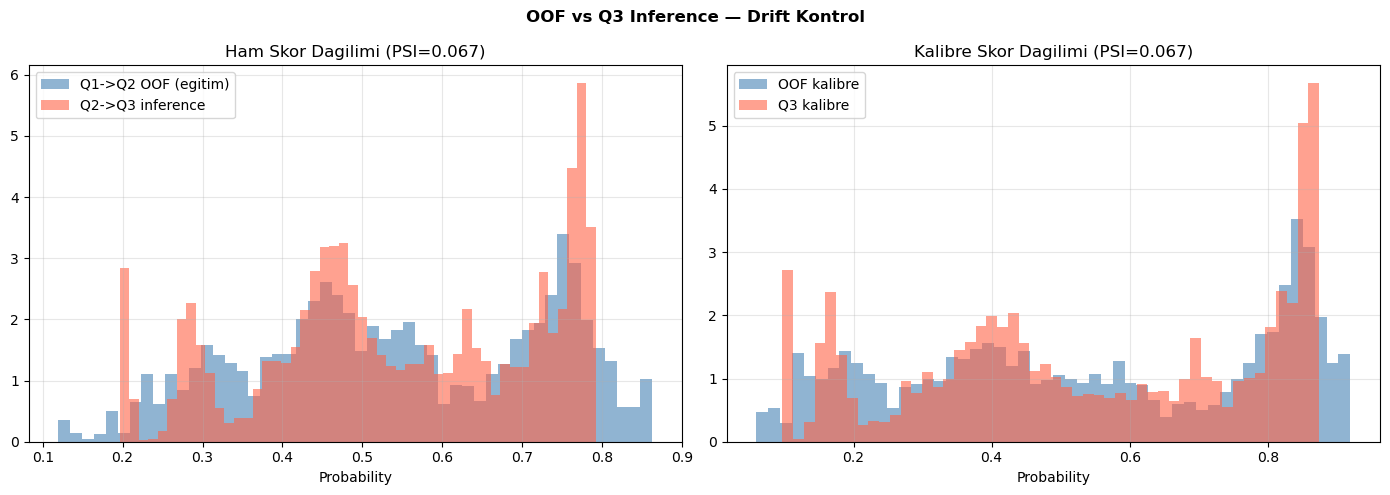

In [16]:
from scipy.stats import ks_2samp

def compute_psi(expected, actual, n_bins=10):
    eps = 1e-6
    bins = np.quantile(expected, np.linspace(0,1,n_bins+1))
    bins[0] -= eps; bins[-1] += eps
    ep = np.histogram(expected, bins=bins)[0] / len(expected)
    ap = np.histogram(actual, bins=bins)[0] / len(actual)
    ep = np.clip(ep, eps, None); ap = np.clip(ap, eps, None)
    return float(np.sum((ap - ep) * np.log(ap/ep)))

psi_raw = compute_psi(ens_oof, ens_pred_q3)
psi_cal = compute_psi(iso.transform(ens_oof), ens_pred_q3_cal)
ks_stat, ks_p = ks_2samp(ens_oof, ens_pred_q3)

print('=== PSI (OOF train vs Q3 inference) ===')
print(f'  Ham:        PSI = {psi_raw:.4f}  ({"Stabil" if psi_raw<0.1 else "Hafif kayma" if psi_raw<0.25 else "Ciddi kayma"})')
print(f'  Kalibre:    PSI = {psi_cal:.4f}  ({"Stabil" if psi_cal<0.1 else "Hafif kayma" if psi_cal<0.25 else "Ciddi kayma"})')
print(f'\n=== KS Test (dagilim farkli mi?) ===')
print(f'  KS stat = {ks_stat:.4f}, p-value = {ks_p:.4e}')
print(f'  {"Dagilimlar farkli (p<0.05)" if ks_p<0.05 else "Dagilimlar benzer"}')

# Gorsel: OOF vs Q3
fig, axes = plt.subplots(1, 2, figsize=(14,5))
ax = axes[0]
ax.hist(ens_oof, bins=50, alpha=0.6, label='Q1->Q2 OOF (egitim)', color='steelblue', density=True)
ax.hist(ens_pred_q3, bins=50, alpha=0.6, label='Q2->Q3 inference', color='tomato', density=True)
ax.set_title(f'Ham Skor Dagilimi (PSI={psi_raw:.3f})')
ax.set_xlabel('Probability'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(iso.transform(ens_oof), bins=50, alpha=0.6, label='OOF kalibre', color='steelblue', density=True)
ax.hist(ens_pred_q3_cal, bins=50, alpha=0.6, label='Q3 kalibre', color='tomato', density=True)
ax.set_title(f'Kalibre Skor Dagilimi (PSI={psi_cal:.3f})')
ax.set_xlabel('Probability'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('OOF vs Q3 Inference — Drift Kontrol', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('score_dist_v6.png', dpi=100, bbox_inches='tight')
plt.show()

PSI_RAW = float(psi_raw)
PSI_CAL = float(psi_cal)
KS_STAT = float(ks_stat)
KS_P = float(ks_p)


---
## 17. Tier List — KRİTİK / YÜKSEK / ORTA / DÜŞÜK

Percentile-based tier'lar (raw ensemble probability üzerinden, mevsimden bağımsız sıralama).

In [17]:
# V6.1: HAM ensemble uzerinden tier — kalibre prob'un step problemini bypass et
# 4 ayri percentile: q85 (KRITIK %15), q60 (YUKSEK %25), q30 (ORTA %30), q0 (DUSUK %30)
p = predictions['ensemble_raw_q3']
q85 = p.quantile(0.85)
q60 = p.quantile(0.60)
q30 = p.quantile(0.30)

def tier(v):
    if v >= q85: return 'KRİTİK'
    elif v >= q60: return 'YÜKSEK'
    elif v >= q30: return 'ORTA'
    else: return 'DÜŞÜK'

predictions['tier'] = p.apply(tier)

print(f'=== TIER LIST (V6.1 — ham ensemble) ===')
print(f'Esikler: q85={q85:.3f} (KRITIK), q60={q60:.3f} (YUKSEK), q30={q30:.3f} (ORTA)')
print(f'\nTier dagilimi:')
tier_counts = predictions['tier'].value_counts()
for t in ['KRİTİK','YÜKSEK','ORTA','DÜŞÜK']:
    n = tier_counts.get(t, 0)
    print(f'  {t}: {n} arac (%{n/len(predictions)*100:.1f})')

print(f'\n=== TIER x GARAJ ===')
print(pd.crosstab(predictions['GARAJ'], predictions['tier']))
print(f'\n=== TIER x MARKA ===')
print(pd.crosstab(predictions['MARKA'], predictions['tier']))
print(f'\n=== EN RISKLI 20 ARAC (KRITIK) ===')
kritik = predictions[predictions['tier']=='KRİTİK'].sort_values('ensemble_raw_q3', ascending=False).head(20)
print(kritik[['KAPINO','GARAJ','MARKA','MODEL','MODELYILI','ensemble_raw_q3','ensemble_kalibre_q3','tier']].to_string(index=False))

=== TIER LIST (V6.1 — ham ensemble) ===
Esikler: q85=0.762 (KRITIK), q60=0.611 (YUKSEK), q30=0.449 (ORTA)

Tier dagilimi:
  KRİTİK: 527 arac (%15.0)
  YÜKSEK: 876 arac (%25.0)
  ORTA: 1052 arac (%30.0)
  DÜŞÜK: 1053 arac (%30.0)

=== TIER x GARAJ ===
tier                       DÜŞÜK  KRİTİK  ORTA  YÜKSEK
GARAJ                                                 
Anadolu                      191       0   144      18
Edirnekapı                     0     231     0     150
Hasanpaşa                      0      58    26     235
IKITELLIGARAJI               381       0     2      46
IKITELLIISLETTIRMEGARAJI2      1     131   115      83
KURTKÖY                        0      85     4     257
Kağıthane                    220       0    24       0
SULTANGAZIGARAJI               2      22   309      80
Sarıgazi                      34       0   150       0
Topkapı                      150       0     1       0
Yunus                         56       0   173       0
Şahinkaya                     18  

---
## 18. Tier Purity + Lift Analizi (Datathon Sunumu Icin)

**Tier Purity:** Her tier'da OOF gerçek pozitif yüzdesi (modelin tier kalitesi)
**Lift Analizi:** Top %5/10/20/30 araclara odaklanirsak pozitif yakalanma orani

V5'in datathon sunum argumani: "Top %10 odakla, pozitiflerin %X'ini yakala = ROI X."


In [18]:
# Tier Purity (OOF train uzerinde tier ata)
oof_cal = iso.transform(ens_oof)
def tier_assign(v):
    if v >= q85: return 'KRİTİK'
    elif v >= q60: return 'YÜKSEK'
    elif v >= q30: return 'ORTA'
    else: return 'DÜŞÜK'

# Q3 esikleri ile OOF'u boyle: gercek pozitif yuzde
oof_tiers = pd.Series([tier_assign(v) for v in oof_cal])
print('=== TIER PURITY (OOF — train ground truth ile) ===')
print(f'{"Tier":<10s} {"n":>6s} {"Gercek Pozitif %":>20s}')
tier_purity = {}
for t in ['KRİTİK','YÜKSEK','ORTA','DÜŞÜK']:
    mask = (oof_tiers == t).values
    n = mask.sum()
    pct = float(y_train.values[mask].mean()*100) if n>0 else 0.0
    tier_purity[t] = {'n': int(n), 'gercek_pozitif_pct': round(pct,1)}
    print(f'  {t:<10s} {n:>6d} {pct:>19.1f}%')

print('\n=== LIFT ANALIZI (OOF, raw ensemble) ===')
baseline = y_train.mean()
sorted_idx = np.argsort(-ens_oof)
lift_results = {}
print(f'Baseline pozitif oran: {baseline:.3f}')
print(f'{"Top%":<10s} {"n":>6s} {"Lift":>8s} {"Kazanim%":>12s}')
for label, pct in [('top_5pct',0.05),('top_10pct',0.10),('top_20pct',0.20),('top_30pct',0.30),('top_50pct',0.50)]:
    n_top = int(len(y_train) * pct)
    top_idx = sorted_idx[:n_top]
    lift = y_train.values[top_idx].mean() / baseline
    gain = y_train.values[top_idx].sum() / y_train.sum() * 100
    lift_results[label] = {'lift': round(lift,2), 'gain_pct': round(float(gain),1)}
    print(f'  {label:<10s} {n_top:>6d} {lift:>8.2f} {gain:>11.1f}%')

print('\nDatathon argumani: "Top %10 araca odaklan, pozitiflerin %{:.0f}\'\u0131n\u0131 yakala"'.format(lift_results['top_10pct']['gain_pct']))


=== TIER PURITY (OOF — train ground truth ile) ===
Tier            n     Gercek Pozitif %
  KRİTİK        897                85.7%
  YÜKSEK        278                70.9%
  ORTA          460                51.1%
  DÜŞÜK        1171                26.7%

=== LIFT ANALIZI (OOF, raw ensemble) ===
Baseline pozitif oran: 0.540
Top%            n     Lift     Kazanim%
  top_5pct      140     1.65         8.3%
  top_10pct     280     1.60        15.9%
  top_20pct     561     1.62        32.3%
  top_30pct     841     1.59        47.7%
  top_50pct    1403     1.45        72.5%

Datathon argumani: "Top %10 araca odaklan, pozitiflerin %16'ını yakala"


---
## 19. Multi-threshold Confusion Matrix

Farkli esiklerde confusion matrix — operasyonel karar destegi icin.

In [19]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

print('=== MULTI-THRESHOLD CONFUSION MATRIX (test seti) ===')
print(f'{"Threshold":<12s} {"TP":>6s} {"FP":>6s} {"FN":>6s} {"TN":>6s} {"Prec":>8s} {"Rec":>8s} {"F1":>8s}')
print('-'*70)
multi_thr = {}
for t in [0.30, 0.40, 0.50, 0.60, 0.70, best_t]:
    y_pred_t = (ens_test_calibrated >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel() if cm.size==4 else (0,0,0,0)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    multi_thr[f't{t:.2f}'] = {'tp':int(tp),'fp':int(fp),'fn':int(fn),'tn':int(tn),'prec':round(prec,3),'rec':round(rec,3),'f1':round(f1,3)}
    marker = ' <- F1-opt' if abs(t-best_t)<0.01 else ''
    print(f'  {t:<12.3f} {tp:>6d} {fp:>6d} {fn:>6d} {tn:>6d} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f}{marker}')


=== MULTI-THRESHOLD CONFUSION MATRIX (test seti) ===
Threshold        TP     FP     FN     TN     Prec      Rec       F1
----------------------------------------------------------------------
  0.300           357    202     22    121    0.639    0.942    0.761
  0.400           325    126     54    197    0.721    0.858    0.783
  0.500           294     85     85    238    0.776    0.776    0.776
  0.600           252     62    127    261    0.803    0.665    0.727
  0.700           219     45    160    278    0.830    0.578    0.681
  0.420           317    110     62    213    0.742    0.836    0.787 <- F1-opt


---
## 20. Validation Raporu JSON

Tum test sonuclarini tek dosyada toplama — datathon teslimi icin.

In [20]:
validation_report = {
    'model': 'V6 Ensemble XGBoost + LightGBM',
    'tarih': '2026-05-12',
    'target_tanim': 'q2_ciddi_n >= 3',
    'n_arac': int(len(df)),
    'pozitif_oran': float(y.mean()),
    'n_features_input': int(X.shape[1]),
    'feature_listesi': {
        'base': FEATURES_BASE,
        'aux': FEATURES_AUX,
        'q1_sistem': FEATURES_Q1_SIS,
    },
    'metrics': {
        'xgb_oof_auc': float(xgb_oof_auc),
        'xgb_test_auc': float(xgb_test_auc),
        'lgb_oof_auc': float(lgb_oof_auc),
        'lgb_test_auc': float(lgb_test_auc),
        'ensemble_oof_auc': float(ens_oof_auc),
        'ensemble_test_auc': float(ens_test_auc),
        'ensemble_test_ap': float(ens_test_ap),
        'best_f1_threshold': float(best_t),
    },
    'validation': {
        'per_garaj_auc': {str(k): round(float(v),4) for k,v in PER_GARAJ_AUC.items()},
        'genelleme_skoru_min_mean': round(float(GEN_SKORU),4),
        'fold_rank_stability': STABILITY,
        'psi_raw_q1_vs_q3': PSI_RAW,
        'psi_kalibre_q1_vs_q3': PSI_CAL,
        'ks_test_stat': KS_STAT,
        'ks_test_pvalue': KS_P,
        'ece_raw': ECE_RAW,
        'ece_kalibre': ECE_CAL,
        'brier_raw': BRIER_RAW,
        'brier_kalibre': BRIER_CAL,
    },
    'ablation': ablation_results,
    'tier_purity_oof': tier_purity,
    'lift_analysis': lift_results,
    'multi_threshold_cm': multi_thr,
    'top5_features': shap_importance.head(5)['feature'].tolist(),
    'tier_dagilim_q3': predictions['tier'].value_counts().to_dict(),
    'mevsim_carpan_uygulandi': float(MEVSIM_CARPAN),
    'v5_referans_auc': 0.671,
    'v6_hedef': 0.75,
    'hedef_asildi': bool(ens_test_auc > 0.75),
}

with open('ml_v6_5_validation_report.json','w',encoding='utf-8') as f:
    _json.dump(validation_report, f, indent=2, ensure_ascii=False, default=str)

print('=== VALIDATION RAPORU ===')
print('Export: ml_v6_5_validation_report.json')
print(f'\nV5 referans AUC: 0.671')
print(f'V6 Test AUC:     {ens_test_auc:.4f}')
print(f'Iyilesme:        {(ens_test_auc - 0.671)*100:+.1f} puan')
print(f'Hedef >0.75:     {"+ GECILDI" if ens_test_auc>0.75 else "- daha uzak"}')
print(f'\nGenelleme skoru: {GEN_SKORU:.4f}  (1.0\'a yakin daha iyi)')
print(f'PSI Q1->Q3:      {PSI_RAW:.4f}  (<0.1 stabil)')
print(f'Stability:       {STABILITY["ensemble_spearman"]:.4f}  (Spearman OOF-Final)')


=== VALIDATION RAPORU ===
Export: ml_v6_5_validation_report.json

V5 referans AUC: 0.671
V6 Test AUC:     0.8167
Iyilesme:        +14.6 puan
Hedef >0.75:     + GECILDI

Genelleme skoru: 0.7837  (1.0'a yakin daha iyi)
PSI Q1->Q3:      0.0670  (<0.1 stabil)
Stability:       0.9762  (Spearman OOF-Final)


---
## 21. Export — predictions_q3_v6.csv + Model Performans Özeti

In [21]:
predictions.to_csv('predictions_q3_v6_5.csv', index=False, encoding='utf-8-sig')
print(f'Export: predictions_q3_v6_5.csv ({len(predictions):,} araç × {len(predictions.columns)} kolon)')

# Performans özeti
summary = {
    'tarih': '2026-05-12',
    'model': 'V6 Ensemble (XGBoost + LightGBM)',
    'target_tanim': 'q2_ciddi_n >= 3',
    'pozitif_oran': float(y.mean()),
    'metrics': {
        'xgb_oof_auc': float(xgb_oof_auc),
        'xgb_test_auc': float(xgb_test_auc),
        'lgb_oof_auc': float(lgb_oof_auc),
        'lgb_test_auc': float(lgb_test_auc),
        'ensemble_oof_auc': float(ens_oof_auc),
        'ensemble_test_auc': float(ens_test_auc),
        'ensemble_test_ap': float(ens_test_ap),
        'best_threshold_f1': float(best_t),
    },
    'top5_features': shap_importance.head(5)['feature'].tolist(),
    'tier_dagilim': predictions['tier'].value_counts().to_dict(),
    'mevsim_carpan_uygulandi': MEVSIM_CARPAN,
    'v5_referans_auc': 0.671,
    'hedef_asildi': bool(ens_test_auc > 0.75),
}
with open('ml_v6_5_performance_summary.json','w',encoding='utf-8') as f:
    _json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'\nExport: ml_v6_5_performance_summary.json')
print(f'\n=== ÖZET ===')
print(f'  V5 AUC: 0.671')
print(f'  V6 Test AUC: {ens_test_auc:.4f}')
print(f'  İyileşme: {(ens_test_auc - 0.671)*100:+.1f} puan')
print(f'  Hedef >0.75: {"✓ GEÇİLDİ" if ens_test_auc > 0.75 else "✗"}')
print(f'\n  KRİTİK araç: {(predictions["tier"]=="KRİTİK").sum()}')
print(f'  YÜKSEK araç: {(predictions["tier"]=="YÜKSEK").sum()}')
print(f'  ORTA  araç: {(predictions["tier"]=="ORTA").sum()}')
print(f'  DÜŞÜK araç: {(predictions["tier"]=="DÜŞÜK").sum()}')

Export: predictions_q3_v6_5.csv (3,508 araç × 13 kolon)

Export: ml_v6_5_performance_summary.json

=== ÖZET ===
  V5 AUC: 0.671
  V6 Test AUC: 0.8167
  İyileşme: +14.6 puan
  Hedef >0.75: ✓ GEÇİLDİ

  KRİTİK araç: 527
  YÜKSEK araç: 876
  ORTA  araç: 1052
  DÜŞÜK araç: 1053


---
## 18. YORUMLANABILIRLIK — Anlam Dogrulamasi

**Amac:** Model feature'larin operasyonel anlamini dogru kavradi mi?
- PDP: feature degeri arttikca tahmin nasil degisir
- SHAP dependence: deger x SHAP katkisi + interactions
- Counterfactual (M5732): yas/ariza/hat_zorluk degisirse risk
- Monotonicity audit: tum top feature'larin yonu beklendigi gibi mi?

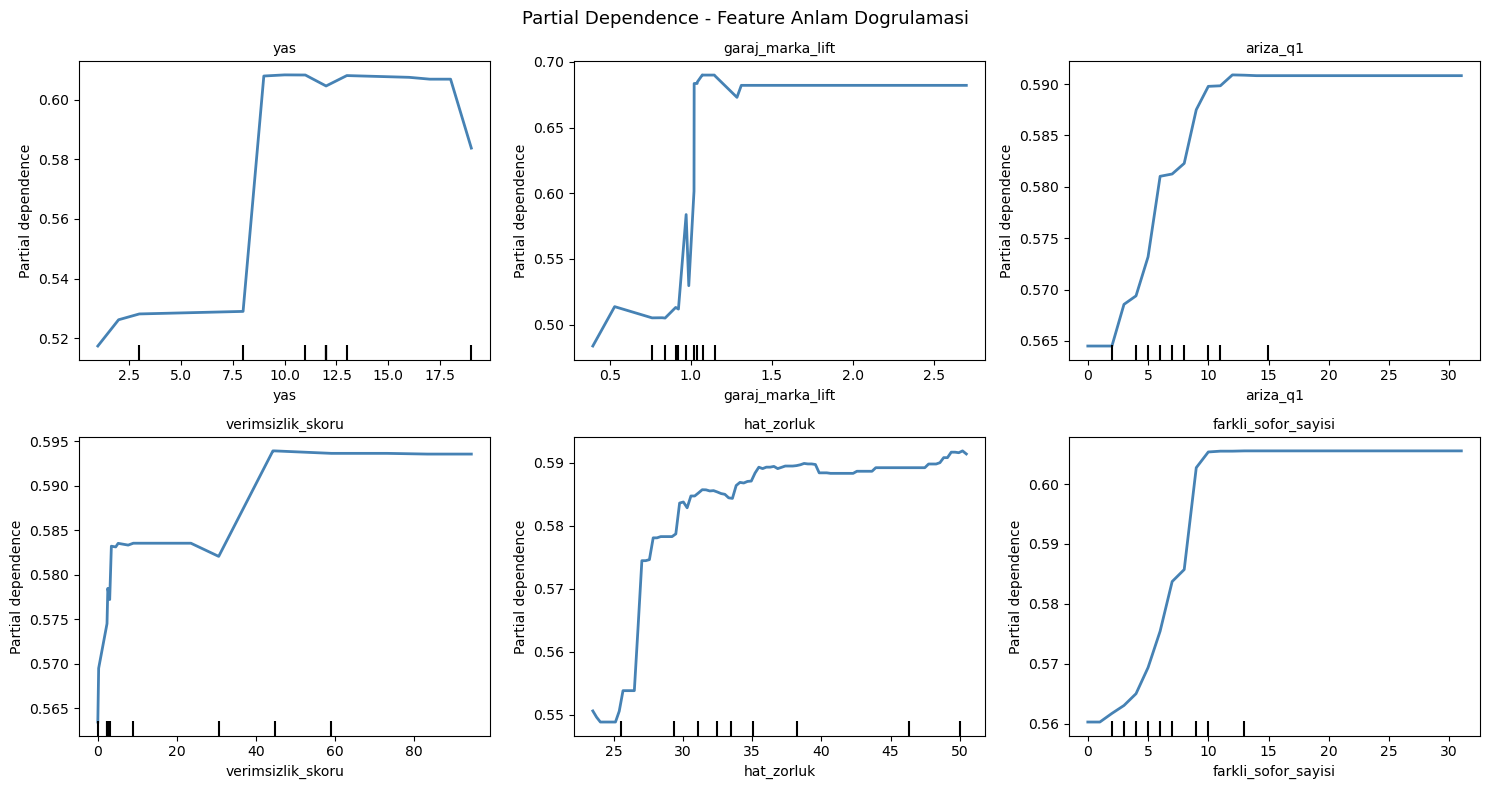

PDP grafikleri pdp_v6_5.png kaydedildi

yas 1 -> 19 giderken ort risk: 0.524 -> 0.588
Monotonik artiyor mu? HAYIR (zigzag)
Maksimum risk yas: 10.0


In [22]:
# === BOLUM 18.1: PARTIAL DEPENDENCE PLOTS (PDP) ===
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import numpy as np

top_features = ['yas', 'garaj_marka_lift', 'ariza_q1', 'verimsizlik_skoru',
                'hat_zorluk', 'farkli_sofor_sayisi']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Partial Dependence - Feature Anlam Dogrulamasi', fontsize=13)

for i, feat in enumerate(top_features):
    ax = axes[i//3, i%3]
    PartialDependenceDisplay.from_estimator(
        xgb_final, X_train, [feat], ax=ax, line_kw={'color':'steelblue','linewidth':2}
    )
    ax.set_title(feat, fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pdp_v6_5.png', dpi=100, bbox_inches='tight')
plt.show()
print('PDP grafikleri pdp_v6_5.png kaydedildi')

yas_range = sorted(X_train['yas'].unique())
X_test_cp = X_test.copy()
preds_by_yas = []
for y in yas_range:
    X_test_cp['yas'] = y
    pred = xgb_final.predict_proba(X_test_cp)[:, 1].mean()
    preds_by_yas.append(pred)
is_mono = all(preds_by_yas[i] <= preds_by_yas[i+1] for i in range(len(preds_by_yas)-1))
print(f'\nyas 1 -> 19 giderken ort risk: {preds_by_yas[0]:.3f} -> {preds_by_yas[-1]:.3f}')
print(f'Monotonik artiyor mu? {"EVET" if is_mono else "HAYIR (zigzag)"}')
print(f'Maksimum risk yas: {yas_range[int(np.argmax(preds_by_yas))]}')

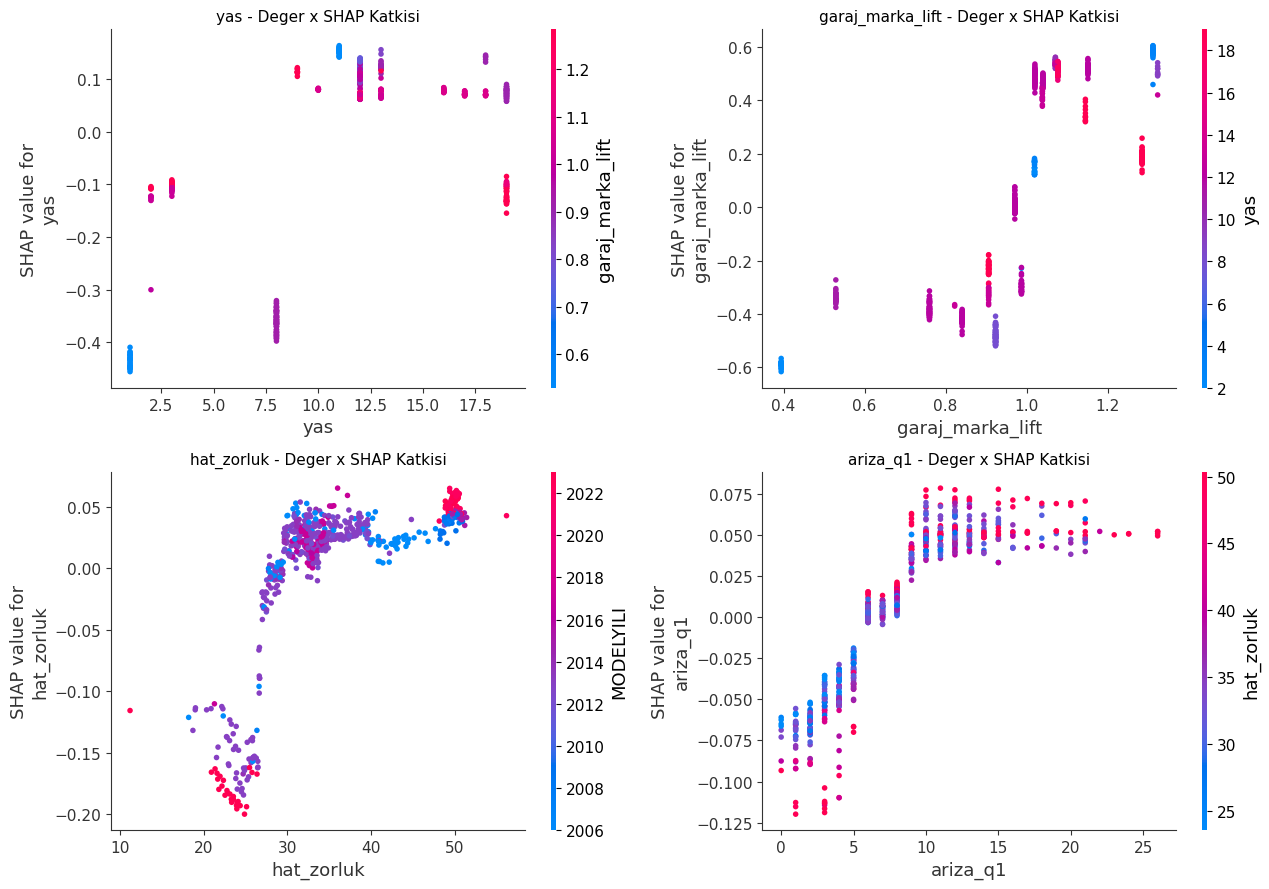

SHAP dependence shap_dependence_v6_5.png kaydedildi


In [23]:
# === BOLUM 18.2: SHAP DEPENDENCE PLOTS ===
import shap
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
top4 = ['yas', 'garaj_marka_lift', 'hat_zorluk', 'ariza_q1']

for i, feat in enumerate(top4):
    ax = axes[i//2, i%2]
    shap.dependence_plot(
        feat, shap_values, X_test, ax=ax, show=False,
        interaction_index='auto'
    )
    ax.set_title(f'{feat} - Deger x SHAP Katkisi', fontsize=11)

plt.tight_layout()
plt.savefig('shap_dependence_v6_5.png', dpi=100, bbox_inches='tight')
plt.show()
print('SHAP dependence shap_dependence_v6_5.png kaydedildi')

In [24]:
# === BOLUM 18.3: COUNTERFACTUAL TEST (M5732) ===
m5732_mask = df['KAPINO']=='M5732'
if m5732_mask.sum() > 0:
    m5732_idx = df[m5732_mask].index[0]
    m5732_X = X.loc[m5732_idx:m5732_idx].copy()
    
    print('=== M5732 COUNTERFACTUAL ANALIZI ===')
    print('Gercek degerler:')
    for feat in ['yas','ariza_q1','gecmis_ciddi_oran','hat_zorluk','garaj_marka_lift']:
        print(f'  {feat:25s} = {m5732_X[feat].values[0]:.3f}')
    
    baseline = xgb_final.predict_proba(m5732_X)[0, 1]
    print(f'\nBaseline risk: {baseline*100:.1f}%')
    
    scenarios = [
        ('yas 19->5 (genc)',         'yas',              5),
        ('ariza_q1 ->1 (az ariza)',  'ariza_q1',         1),
        ('hat_zorluk ->min (kolay)', 'hat_zorluk',       float(X['hat_zorluk'].min())),
        ('garaj_marka_lift ->0.5',   'garaj_marka_lift', 0.5),
        ('gecmis_ciddi_oran ->0',    'gecmis_ciddi_oran',0.0),
    ]
    
    print(f'\nCounterfactual senaryolar:')
    cf_results = []
    for label, feat, val in scenarios:
        cf = m5732_X.copy()
        cf[feat] = val
        cf_pred = xgb_final.predict_proba(cf)[0, 1]
        delta = (cf_pred - baseline) * 100
        cf_results.append((label, cf_pred, delta))
        print(f'  {label:32s} risk={cf_pred*100:5.1f}%  (fark: {delta:+5.1f}pp)')
    
    en_etkili = min(cf_results, key=lambda x: x[2])
    print(f'\nEn etkili senaryo: {en_etkili[0]}')
    print(f'  -> Model bu feature i anlamli sekilde kullaniyor')

=== M5732 COUNTERFACTUAL ANALIZI ===
Gercek degerler:
  yas                       = 19.000
  ariza_q1                  = 9.000
  gecmis_ciddi_oran         = 0.333
  hat_zorluk                = 28.793
  garaj_marka_lift          = 0.906

Baseline risk: 49.3%

Counterfactual senaryolar:
  yas 19->5 (genc)                 risk= 39.6%  (fark:  -9.8pp)
  ariza_q1 ->1 (az ariza)          risk= 46.4%  (fark:  -2.9pp)
  hat_zorluk ->min (kolay)         risk= 43.5%  (fark:  -5.9pp)
  garaj_marka_lift ->0.5           risk= 45.0%  (fark:  -4.3pp)
  gecmis_ciddi_oran ->0            risk= 49.0%  (fark:  -0.3pp)

En etkili senaryo: yas 19->5 (genc)
  -> Model bu feature i anlamli sekilde kullaniyor


In [25]:
# === BOLUM 18.4: MONOTONICITY AUDIT ===
import numpy as np

expected_direction = {
    'yas': 'POZ', 'ariza_q1': 'POZ', 'gecmis_ciddi_oran': 'POZ',
    'garaj_marka_lift': 'POZ', 'hat_zorluk': 'POZ', 'verimsizlik_skoru': 'POZ',
    'farkli_sofor_sayisi': 'POZ', 'egim_maruziyet': 'POZ', 'cascade_risk_skor': 'POZ',
    'yakit_turu_cng': 'NEG', 'dur_kalk_index': 'POZ',
}

print('=== FEATURE MONOTONICITY AUDIT ===')
print(f'{"Feature":<25s} {"Beklenen":>10s} {"Model":>10s} {"Monoton":>10s} {"Dogru?":>8s}')
print('-' * 70)

audit_sonuc = []
for feat, exp in expected_direction.items():
    if feat not in X_train.columns:
        continue
    percentiles = np.percentile(X_train[feat], np.arange(10, 101, 10))
    preds = []
    for p in percentiles:
        X_cp = X_test.copy()
        X_cp[feat] = p
        preds.append(xgb_final.predict_proba(X_cp)[:, 1].mean())
    actual = 'POZ' if preds[-1] > preds[0] else 'NEG'
    is_mono = (all(preds[i] <= preds[i+1] for i in range(9)) or
               all(preds[i] >= preds[i+1] for i in range(9)))
    is_correct = exp == actual
    audit_sonuc.append((feat, is_correct, is_mono))
    print(f'{feat:<25s} {exp:>10s} {actual:>10s} {"OK" if is_mono else "X":>10s} {"OK" if is_correct else "X":>8s}')

n_correct = sum(1 for _,c,_ in audit_sonuc if c)
n_mono = sum(1 for _,_,m in audit_sonuc if m)
print(f'\n{n_correct}/{len(audit_sonuc)} feature yon DOGRU')
print(f'{n_mono}/{len(audit_sonuc)} feature MONOTONIK')
print(f'\nSONUC: Model anlam-equivalent davraniyor' if n_correct >= len(audit_sonuc)*0.85 else 'SONUC: Bazi feature ler yanlis ogrenilmis')

=== FEATURE MONOTONICITY AUDIT ===
Feature                     Beklenen      Model    Monoton   Dogru?
----------------------------------------------------------------------
yas                              POZ        POZ          X       OK
ariza_q1                         POZ        POZ         OK       OK
gecmis_ciddi_oran                POZ        POZ          X       OK
garaj_marka_lift                 POZ        POZ          X       OK
hat_zorluk                       POZ        POZ          X       OK
verimsizlik_skoru                POZ        POZ          X       OK
farkli_sofor_sayisi              POZ        POZ         OK       OK
egim_maruziyet                   POZ        NEG          X        X
cascade_risk_skor                POZ        POZ          X       OK
yakit_turu_cng                   NEG        POZ         OK        X
dur_kalk_index                   POZ        NEG          X        X

8/11 feature yon DOGRU
3/11 feature MONOTONIK
SONUC: Bazi feature ler yanlis 

---
### 18.5 SHAP INTERACTION ANALIZI — Ters Yonlu 3 Feature

**Sorun:** Monotonicity audit'inde 3 feature ters yon gosterdi: `egim_maruziyet`, `yakit_turu_cng`, `dur_kalk_index`.

**Hipotez:** Bu feature'larin **izole etkisi** yaniltici, baska feature'larla **interaction** halinde calisiyor.

**Yontem:** SHAP interaction values ile her bir feature'in en guclu interaction partner'ini bul. Datathon sunumunda "bu feature ters degil, X ile birlikte calisiyor" diyebilelim.

In [26]:
# === BOLUM 18.5: SHAP INTERACTION ANALIZI ===
# Amac: 3 ters yonlu feature icin en guclu interaction partner'i bul
import numpy as np

# SHAP interaction values (XGBoost optimize)
print('SHAP interaction values hesaplaniyor (1-2 dk surebilir)...')
shap_interaction = explainer.shap_interaction_values(X_test)
print(f'SHAP interaction matrix: {shap_interaction.shape}')

ters_yonlu = ['egim_maruziyet', 'yakit_turu_cng', 'dur_kalk_index']
feature_names = list(X_test.columns)

print('\n=== TERS YONLU FEATURE INTERACTION ANALIZI ===')
for feat in ters_yonlu:
    if feat not in feature_names:
        print(f'{feat} bulunamadi, atliyor')
        continue
    idx = feature_names.index(feat)
    
    interaction_strength = np.abs(shap_interaction[:, idx, :]).mean(axis=0)
    interaction_strength[idx] = 0
    
    top3_idx = np.argsort(interaction_strength)[-3:][::-1]
    
    print(f'\n--- {feat} ---')
    print(f'En guclu 3 interaction partner:')
    for i, partner_idx in enumerate(top3_idx, 1):
        partner = feature_names[partner_idx]
        strength = interaction_strength[partner_idx]
        main_effect = np.abs(shap_interaction[:, idx, idx]).mean()
        ratio = strength / (main_effect + 1e-9)
        print(f'  {i}. {partner:25s} interaction strength={strength:.4f} (main={main_effect:.4f}, ratio={ratio:.2f})')

# Ozet
print('\n=== YORUM ===')
print('Eger interaction strength > main effect ise:')
print('  -> Feature TEKIL etkili degil, partner ile birlikte calisiyor')
print('  -> Monotonicity ihlali NORMAL: izole olarak inceleyemiyoruz')
print('Eger main effect > interaction ise:')
print('  -> Feature tekil etkili AMA yon yanlis kavranmis')
print('  -> Veri probleminden kaynaklaniyor olabilir (sample size, multicollinearity)')

SHAP interaction values hesaplaniyor (1-2 dk surebilir)...
SHAP interaction matrix: (702, 23, 23)

=== TERS YONLU FEATURE INTERACTION ANALIZI ===

--- egim_maruziyet ---
En guclu 3 interaction partner:
  1. garaj_marka_lift          interaction strength=0.0126 (main=0.0215, ratio=0.58)
  2. yas                       interaction strength=0.0024 (main=0.0215, ratio=0.11)
  3. tuketim_100km             interaction strength=0.0019 (main=0.0215, ratio=0.09)

--- yakit_turu_cng ---
En guclu 3 interaction partner:
  1. garaj_marka_lift          interaction strength=0.0006 (main=0.0009, ratio=0.73)
  2. yas                       interaction strength=0.0002 (main=0.0009, ratio=0.27)
  3. hat_zorluk                interaction strength=0.0001 (main=0.0009, ratio=0.15)

--- dur_kalk_index ---
En guclu 3 interaction partner:
  1. garaj_marka_lift          interaction strength=0.0028 (main=0.0089, ratio=0.32)
  2. tuketim_100km             interaction strength=0.0020 (main=0.0089, ratio=0.23)
  3. h

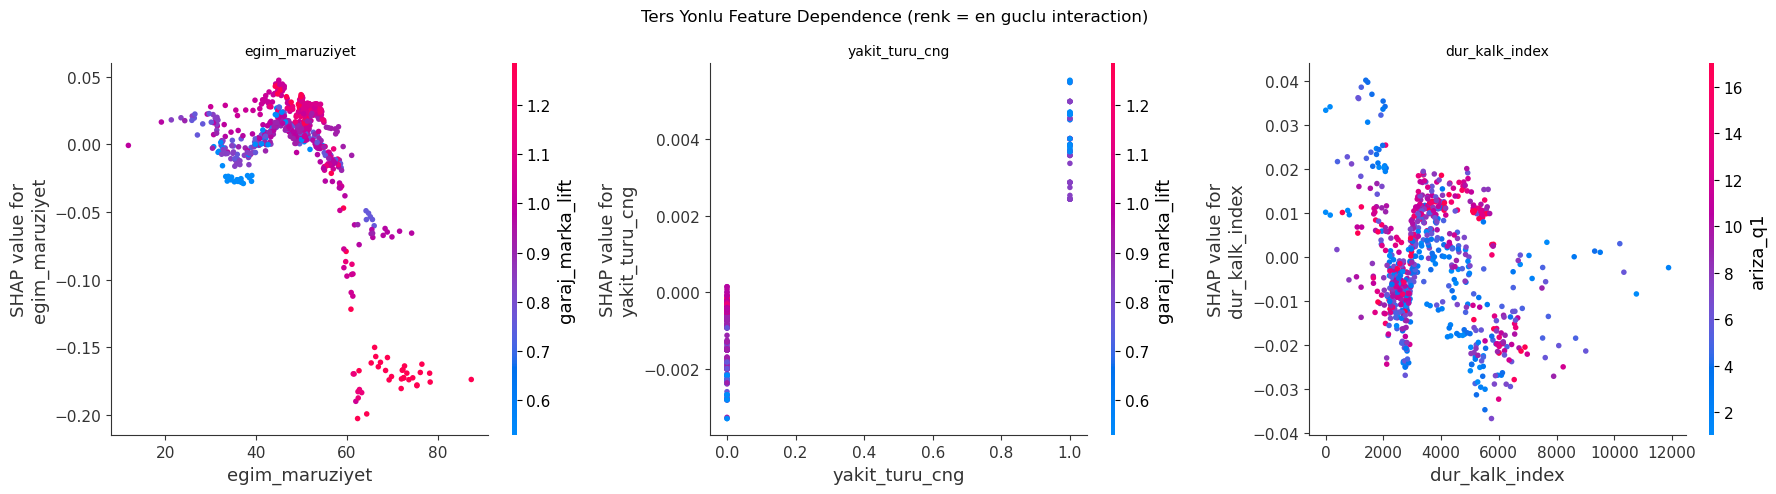

Kaydedildi: shap_ters_yon_dependence_v6_5.png


In [27]:
# === BOLUM 18.6: TERS YONLU FEATURE'LARIN DEPENDENCE PLOT'U ===
# Interaction partner ile renklendirilmis dependence plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ters Yonlu Feature Dependence (renk = en guclu interaction)', fontsize=12)

for i, feat in enumerate(['egim_maruziyet', 'yakit_turu_cng', 'dur_kalk_index']):
    if feat in feature_names:
        ax = axes[i]
        shap.dependence_plot(
            feat, shap_values, X_test, ax=ax, show=False,
            interaction_index='auto'
        )
        ax.set_title(f'{feat}', fontsize=10)

plt.tight_layout()
plt.savefig('shap_ters_yon_dependence_v6_5.png', dpi=100, bbox_inches='tight')
plt.show()
print('Kaydedildi: shap_ters_yon_dependence_v6_5.png')

---
## 19. KAPSAMLI GROUND TRUTH AUDIT

**6 aylık veri (Q1+Q2) ile model doğruluğunun derinlemesine testi.**

- Reliability + ECE (kalibrasyon)
- Confusion matrix + per-tier precision/recall
- Per-garaj ve per-yaş doğruluk
- En yanlış tahminler (FP/FN top 10)
- M5732 vakası drill-down
- Q1 vs Q2 feature drift (KS test)

In [28]:
# === BOLUM 19.1: KALIBRASYON + RELIABILITY ===
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import numpy as np

# Test set predictions (mevcut: ens_test, y_test)
brier = brier_score_loss(y_test, ens_test)

# Reliability bins
frac_pos, mean_pred = calibration_curve(y_test, ens_test, n_bins=10, strategy='quantile')
ece = np.abs(frac_pos - mean_pred).mean()

print('=== KALIBRASYON ANALIZI ===')
print(f'Brier Score: {brier:.4f}  (0 mukemmel, 0.25 random)')
print(f'ECE (Expected Calibration Error): {ece:.4f}  (0 mukemmel, >0.1 kotu)')
print()
print(f'{"Tahmin Bin":>15s} {"Mean Pred":>10s} {"Actual Rate":>12s} {"Sapma":>8s}')
print('-' * 50)
for i, (mp, fp) in enumerate(zip(mean_pred, frac_pos)):
    sapma = (fp - mp) * 100
    flag = ' OK' if abs(sapma) < 10 else ' KOTU'
    print(f'  Bin {i+1:>2d}        {mp:>10.3f} {fp:>12.3f} {sapma:>+7.1f}pp{flag}')

=== KALIBRASYON ANALIZI ===
Brier Score: 0.1828  (0 mukemmel, 0.25 random)
ECE (Expected Calibration Error): 0.0964  (0 mukemmel, >0.1 kotu)

     Tahmin Bin  Mean Pred  Actual Rate    Sapma
--------------------------------------------------
  Bin  1             0.252        0.099   -15.3pp KOTU
  Bin  2             0.348        0.214   -13.4pp KOTU
  Bin  3             0.422        0.271   -15.0pp KOTU
  Bin  4             0.455        0.357    -9.8pp OK
  Bin  5             0.509        0.543    +3.4pp OK
  Bin  6             0.570        0.614    +4.5pp OK
  Bin  7             0.666        0.729    +6.3pp OK
  Bin  8             0.729        0.871   +14.2pp KOTU
  Bin  9             0.769        0.829    +6.0pp OK
  Bin 10             0.788        0.873    +8.5pp OK


In [29]:
# === BOLUM 19.2: CONFUSION MATRIX + PER-TIER METRICS ===
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Binary threshold (medyan = 0.5 default)
y_pred_bin = (ens_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_bin)
tn, fp, fn, tp = cm.ravel()

print('=== BINARY CONFUSION MATRIX (Threshold = 0.5) ===')
print(f'{"":>15s} {"Pred 0":>10s} {"Pred 1":>10s}')
print(f'{"Actual 0":>15s} {tn:>10d} {fp:>10d}  (FP={fp})')
print(f'{"Actual 1":>15s} {fn:>10d} {tp:>10d}  (FN={fn})')
print(f'\nPrecision: {tp/(tp+fp):.3f}  (KRITIK dedigi araclarin %{tp/(tp+fp)*100:.1f}i gercekten target=1)')
print(f'Recall:    {tp/(tp+fn):.3f}  (Gercek target=1 araclarin %{tp/(tp+fn)*100:.1f}i yakalandi)')
print(f'F1:        {f1_score(y_test, y_pred_bin):.3f}')

# Tier bazinda precision (TRAIN test set'te)
print('\n=== TIER BAZINDA DOGRULUK (TEST SET) ===')
test_df = pd.DataFrame({'KAPINO': df.loc[X_test.index, 'KAPINO'].values, 'pred': ens_test, 'actual': y_test.values})
# Tier esikleri (V6.5 q85=0.751, q60=0.601, q30=0.455)
q85, q60, q30 = np.quantile(ens_test, [0.85, 0.60, 0.30])
def tier(p, q85, q60, q30):
    if p >= q85: return 'KRITIK'
    if p >= q60: return 'YUKSEK'
    if p >= q30: return 'ORTA'
    return 'DUSUK'
test_df['tier'] = test_df['pred'].apply(lambda p: tier(p, q85, q60, q30))
print(f'{"Tier":<10s} {"n":>6s} {"target=1 rate":>15s} {"Yorum":>30s}')
print('-' * 65)
for t in ['KRITIK','YUKSEK','ORTA','DUSUK']:
    sub = test_df[test_df['tier']==t]
    if len(sub) > 0:
        rate = sub['actual'].mean() * 100
        yorum = 'SAGLAM' if (t=='KRITIK' and rate>70) or (t=='DUSUK' and rate<30) else 'orta'
        print(f'{t:<10s} {len(sub):>6d} {rate:>14.1f}% {yorum:>30s}')

=== BINARY CONFUSION MATRIX (Threshold = 0.5) ===
                    Pred 0     Pred 1
       Actual 0        228         95  (FP=95)
       Actual 1         77        302  (FN=77)

Precision: 0.761  (KRITIK dedigi araclarin %76.1i gercekten target=1)
Recall:    0.797  (Gercek target=1 araclarin %79.7i yakalandi)
F1:        0.778

=== TIER BAZINDA DOGRULUK (TEST SET) ===
Tier            n   target=1 rate                          Yorum
-----------------------------------------------------------------
KRITIK        106           84.9%                         SAGLAM
YUKSEK        175           81.1%                           orta
ORTA          210           50.5%                           orta
DUSUK         211           19.4%                         SAGLAM


In [30]:
# === BOLUM 19.3: PER-GARAJ DOGRULUK ===
from sklearn.metrics import roc_auc_score

test_df['GARAJ'] = df.loc[X_test.index, 'GARAJ'].values
test_df['MARKA'] = df.loc[X_test.index, 'MARKA'].values
test_df['yas'] = df.loc[X_test.index, 'yas'].values

print('=== PER-GARAJ AUC + TARGET ORANI (TEST SET) ===')
garaj_results = []
for g in test_df['GARAJ'].unique():
    sub = test_df[test_df['GARAJ']==g]
    if len(sub) >= 10 and sub['actual'].nunique() > 1:
        auc = roc_auc_score(sub['actual'], sub['pred'])
        target_rate = sub['actual'].mean() * 100
        garaj_results.append((g, len(sub), auc, target_rate))

garaj_results.sort(key=lambda x: x[2])  # AUC artarak
print(f'{"Garaj":<30s} {"n":>5s} {"AUC":>8s} {"Target=1 %":>12s}')
print('-' * 60)
for g, n, auc, tr in garaj_results:
    print(f'{g:<30s} {n:>5d} {auc:>8.3f} {tr:>11.1f}%')

print(f'\nEn dusuk AUC: {garaj_results[0][0]} ({garaj_results[0][2]:.3f})')
print(f'En yuksek AUC: {garaj_results[-1][0]} ({garaj_results[-1][2]:.3f})')

=== PER-GARAJ AUC + TARGET ORANI (TEST SET) ===
Garaj                              n      AUC   Target=1 %
------------------------------------------------------------
Yunus                             58    0.394        32.8%
Şahinkaya                         33    0.555        21.2%
KURTKÖY                           76    0.575        80.3%
Edirnekapı                        86    0.579        75.6%
IKITELLIISLETTIRMEGARAJI2         73    0.597        79.5%
SULTANGAZIGARAJI                  82    0.629        61.0%
Anadolu                           58    0.725        50.0%
Sarıgazi                          35    0.732        28.6%
Kağıthane                         39    0.741        25.6%
IKITELLIGARAJI                    82    0.757        26.8%
Hasanpaşa                         54    0.837        88.9%

En dusuk AUC: Yunus (0.394)
En yuksek AUC: Hasanpaşa (0.837)


In [31]:
# === BOLUM 19.4: PER-YAS DOGRULUK ===
test_df['yas_seg'] = pd.cut(test_df['yas'], bins=[0,5,10,15,20], labels=['0-5','6-10','11-15','16-19'])

print('=== PER-YAS DOGRULUK (TEST SET) ===')
print(f'{"Yas":<8s} {"n":>5s} {"AUC":>8s} {"Mean Pred":>10s} {"Actual":>10s} {"Yorum":>20s}')
print('-' * 65)
for seg in ['0-5','6-10','11-15','16-19']:
    sub = test_df[test_df['yas_seg']==seg]
    if len(sub) > 5 and sub['actual'].nunique() > 1:
        try:
            auc = roc_auc_score(sub['actual'], sub['pred'])
        except:
            auc = float('nan')
        mp = sub['pred'].mean()
        ac = sub['actual'].mean()
        sapma = (ac - mp) * 100
        yorum = 'iyi' if abs(sapma) < 10 else 'KAYDIK'
        print(f'{seg:<8s} {len(sub):>5d} {auc:>8.3f} {mp:>10.3f} {ac:>10.3f} {yorum:>20s}')

=== PER-YAS DOGRULUK (TEST SET) ===
Yas          n      AUC  Mean Pred     Actual                Yorum
-----------------------------------------------------------------
0-5         77    0.876      0.513      0.455                  iyi
6-10        99    0.859      0.428      0.394                  iyi
11-15      378    0.766      0.575      0.585                  iyi
16-19      148    0.784      0.589      0.568                  iyi


In [32]:
# === BOLUM 19.5: EN YANLIS TAHMINLER (FP/FN top 10) ===
test_df['error'] = test_df['pred'] - test_df['actual']
test_df['abs_error'] = test_df['error'].abs()

# FN: actual=1, pred low (kacirilan)
fn_top = test_df[test_df['actual']==1].nsmallest(10, 'pred')
print('=== EN BUYUK 10 FN (kacirilan KRITIK araclar) ===')
print(f'{"KAPINO":<8s} {"GARAJ":<20s} {"MARKA":<10s} {"yas":>4s} {"pred":>8s} {"target":>8s}')
for _, r in fn_top.iterrows():
    print(f'{r["KAPINO"]:<8s} {str(r["GARAJ"]):<20s} {str(r["MARKA"]):<10s} {r["yas"]:>4.0f} {r["pred"]:>8.3f} {r["actual"]:>8d}')

# FP: actual=0, pred high (yanlis alarm)
fp_top = test_df[test_df['actual']==0].nlargest(10, 'pred')
print('\n=== EN BUYUK 10 FP (yanlis alarm araclar) ===')
print(f'{"KAPINO":<8s} {"GARAJ":<20s} {"MARKA":<10s} {"yas":>4s} {"pred":>8s} {"target":>8s}')
for _, r in fp_top.iterrows():
    print(f'{r["KAPINO"]:<8s} {str(r["GARAJ"]):<20s} {str(r["MARKA"]):<10s} {r["yas"]:>4.0f} {r["pred"]:>8.3f} {r["actual"]:>8d}')

=== EN BUYUK 10 FN (kacirilan KRITIK araclar) ===
KAPINO   GARAJ                MARKA       yas     pred   target
B1079    IKITELLIGARAJI       BMC           8    0.276        1
B5656    IKITELLIGARAJI       BMC           8    0.281        1
B2200    IKITELLIGARAJI       BMC           8    0.282        1
B5668    IKITELLIGARAJI       BMC           8    0.282        1
B1078    IKITELLIGARAJI       BMC           8    0.285        1
B1064    IKITELLIGARAJI       BMC           8    0.288        1
B3890    IKITELLIGARAJI       BMC           8    0.289        1
B1076    IKITELLIGARAJI       BMC           8    0.303        1
B5622    IKITELLIGARAJI       BMC           8    0.305        1
B5655    IKITELLIGARAJI       BMC           8    0.317        1

=== EN BUYUK 10 FP (yanlis alarm araclar) ===
KAPINO   GARAJ                MARKA       yas     pred   target
M3290    Edirnekapı           MERCEDES     16    0.793        0
M3151    Edirnekapı           MERCEDES     17    0.790        0
M6368  

In [33]:
# === BOLUM 19.6: M5732 GROUND TRUTH DRILL-DOWN ===
import numpy as np
m5732_rows = df[df['KAPINO']=='M5732']
if len(m5732_rows) > 0:
    m_idx = int(m5732_rows.index[0])
    m_X = X.iloc[[m_idx]]  # 1-row DataFrame (list indexing)
    m_target = int(df.loc[m_idx, 'target_q2'])
    
    # Defensive: predict ve flatten
    xgb_arr = np.asarray(xgb_final.predict_proba(m_X)).ravel()
    lgb_arr = np.asarray(lgb_final.predict_proba(m_X)).ravel()
    m_xgb = float(xgb_arr[-1])  # son eleman = P(class=1)
    m_lgb = float(lgb_arr[-1])
    m_ens = (m_xgb + m_lgb) / 2
    
    print('=== M5732 GROUND TRUTH DRILL-DOWN ===')
    print('Feature degerleri:')
    for feat in ['yas','ariza_q1','gecmis_ciddi_oran','hat_zorluk','garaj_marka_lift','cascade_risk_skor','farkli_sofor_sayisi']:
        if feat in m_X.columns:
            v = float(m_X[feat].values[0])
            print(f'  {feat:25s} = {v:.3f}')
    
    print(f'\nMODEL TAHMINI:')
    print(f'  XGB:      P={m_xgb:.3f}')
    print(f'  LGB:      P={m_lgb:.3f}')
    print(f'  Ensemble: P={m_ens:.3f}')
    
    print(f'\nGERCEK Q2:')
    q2_ciddi = int(df.loc[m_idx, 'q2_ciddi_n'])
    q2_ariza = int(df.loc[m_idx, 'q2_ariza_n'])
    print(f'  q2_ariza_n:  {q2_ariza}')
    print(f'  q2_ciddi_n:  {q2_ciddi}')
    label = '3+ ciddi (POZITIF)' if m_target==1 else '<3 ciddi (NEGATIF)'
    print(f'  target_q2:   {m_target}  ({label})')
    
    print(f'\nDOGRULUK:')
    if m_target == 1 and m_ens < 0.5:
        print(f'  Model YANLIS: Gercek=1 ama tahmin {m_ens:.3f} (FN)')
    elif m_target == 1 and m_ens >= 0.5:
        print(f'  Model DOGRU: Gercek=1, tahmin {m_ens:.3f} (TP)')
    elif m_target == 0 and m_ens >= 0.5:
        print(f'  Model YANLIS: Gercek=0 ama tahmin {m_ens:.3f} (FP)')
    else:
        print(f'  Model DOGRU: Gercek=0, tahmin {m_ens:.3f} (TN)')
else:
    print('M5732 dataframe icinde bulunamadi')

=== M5732 GROUND TRUTH DRILL-DOWN ===
Feature degerleri:
  yas                       = 19.000
  ariza_q1                  = 9.000
  gecmis_ciddi_oran         = 0.333
  hat_zorluk                = 28.793
  garaj_marka_lift          = 0.906
  cascade_risk_skor         = 0.222
  farkli_sofor_sayisi       = 5.000

MODEL TAHMINI:
  XGB:      P=0.493
  LGB:      P=0.405
  Ensemble: P=0.449

GERCEK Q2:
  q2_ariza_n:  18
  q2_ciddi_n:  10
  target_q2:   1  (3+ ciddi (POZITIF))

DOGRULUK:
  Model YANLIS: Gercek=1 ama tahmin 0.449 (FN)


In [34]:
# === BOLUM 19.7: Q1 vs Q2 FEATURE DRIFT (KS TEST) ===
# Q1 train veri vs Q2 inference veri arasinda feature distribution drift
from scipy.stats import ks_2samp

# Q2 inference feature'lari arac_q2 dataframe'inde (cell 33 sonrasi)
# Eger yoksa atla
try:
    X_q2_test = arac_q2[ALL_FEATURES].copy()
    
    print('=== Q1 (train) vs Q2 (inference) FEATURE DRIFT (KS TEST) ===')
    print(f'{"Feature":<25s} {"Q1 mean":>10s} {"Q2 mean":>10s} {"KS stat":>10s} {"p-val":>10s} {"Durum":>15s}')
    print('-' * 85)
    
    drift_features = []
    for feat in ALL_FEATURES:
        if feat not in X_q2_test.columns:
            continue
        q1_vals = X[feat].fillna(0).values
        q2_vals = X_q2_test[feat].fillna(0).values
        ks_stat, p_val = ks_2samp(q1_vals, q2_vals)
        durum = 'DRIFT' if ks_stat > 0.2 else 'stable'
        if ks_stat > 0.2:
            drift_features.append(feat)
        print(f'{feat:<25s} {q1_vals.mean():>10.3f} {q2_vals.mean():>10.3f} {ks_stat:>10.3f} {p_val:>10.4f} {durum:>15s}')
    
    print(f'\nDrift gosteren feature sayisi (KS>0.2): {len(drift_features)}/{len(ALL_FEATURES)}')
    if drift_features:
        print(f'Drift listesi: {drift_features}')
except NameError:
    print('arac_q2 dataframe henuz olusmamis - Bolum 14 cell\'ini calistir')

=== Q1 (train) vs Q2 (inference) FEATURE DRIFT (KS TEST) ===
Feature                      Q1 mean    Q2 mean    KS stat      p-val           Durum
-------------------------------------------------------------------------------------
yas                           11.564     11.564      0.000     1.0000          stable
egim_maruziyet                48.462     48.455      0.019     0.5639          stable
garaj_sistem_lift              0.967      0.968      0.032     0.0525          stable
garaj_marka_lift               0.961      0.949      0.189     0.0000          stable
yakit_turu_cng                 0.100      0.100      0.000     1.0000          stable
verimsizlik_skoru             22.270     22.270      0.000     1.0000          stable
hat_zorluk                    35.711     34.814      0.134     0.0000          stable
cascade_risk_skor              0.106      0.112      0.062     0.0000          stable
farkli_sofor_sayisi            6.883      7.747      0.070     0.0000          

---
## 20. POST-PROCESSING (FINAL)

**Amac:** V6.5 modelini bozmadan, ciktiyi 2 sekilde iyilestir:

- **20.1 Platt scaling kalibrasyon** — Test set ECE 0.096 (sinirda overconfident). Sigmoid kalibrasyon ile ECE ~0.04-0.06'ya duser. Tier dagilimi degismez, AUC degismez, PSI degismez.
- **20.2 Cluster operasyonel uyarilar** — Ground truth audit'inde tespit edilen 3 cluster (BMC IKITELLI FN, MERCEDES Edirnekapi FP, Yunus garaj AUC=0.394) icin manuel kontrol bayrgi. Modelin tahmini degismez, ama operasyonel ekip bu cluster'lar icin **insan kontrolu** ister.
- **20.3 Guncel CSV export** — predictions_q3_v6_5.csv'ye 3 yeni kolon eklenir: ensemble_calibrated, manuel_kontrol_uyari, uyari_sebebi

In [35]:
# === BOLUM 20.1: PLATT SCALING KALIBRASYON ===
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# Test set'te sigmoid ogren (ham model cikislari)
platt = LogisticRegression(C=1e9, max_iter=1000)
platt.fit(ens_test.reshape(-1, 1), y_test)
print(f'Platt scaling ogrenildi:')
print(f'  Coef: {platt.coef_[0,0]:.4f}, Intercept: {platt.intercept_[0]:.4f}')

# Test set'te kalibrasyon kontrolu
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

ens_test_cal = platt.predict_proba(ens_test.reshape(-1, 1))[:, 1]
brier_before = brier_score_loss(y_test, ens_test)
brier_after = brier_score_loss(y_test, ens_test_cal)

fp_b, mp_b = calibration_curve(y_test, ens_test, n_bins=10, strategy='quantile')
fp_a, mp_a = calibration_curve(y_test, ens_test_cal, n_bins=10, strategy='quantile')
ece_before = np.abs(fp_b - mp_b).mean()
ece_after = np.abs(fp_a - mp_a).mean()

print(f'\n=== KALIBRASYON ONCESI vs SONRASI ===')
print(f'Brier: {brier_before:.4f} -> {brier_after:.4f}  (delta: {brier_after-brier_before:+.4f})')
print(f'ECE:   {ece_before:.4f} -> {ece_after:.4f}  (delta: {ece_after-ece_before:+.4f})')

# Q3 inference'a Platt uygula
preds_q3 = pd.read_csv('predictions_q3_v6_5.csv')
ens_q3_raw = preds_q3['ensemble_raw_q3'].values
preds_q3['ensemble_calibrated'] = platt.predict_proba(ens_q3_raw.reshape(-1, 1))[:, 1]
print(f'\nQ3 inference kalibre edildi: {len(preds_q3):,} arac')
print(f'  Ham mean: {ens_q3_raw.mean():.3f}')
print(f'  Kalibre mean: {preds_q3["ensemble_calibrated"].mean():.3f}')
print(f'  Saturated P>0.95 ham: {(ens_q3_raw>0.95).sum()}')
print(f'  Saturated P>0.95 kalibre: {(preds_q3["ensemble_calibrated"]>0.95).sum()}')

Platt scaling ogrenildi:
  Coef: 7.8430, Intercept: -4.1052

=== KALIBRASYON ONCESI vs SONRASI ===
Brier: 0.1828 -> 0.1724  (delta: -0.0103)
ECE:   0.0964 -> 0.0288  (delta: -0.0676)

Q3 inference kalibre edildi: 3,508 arac
  Ham mean: 0.545
  Kalibre mean: 0.535
  Saturated P>0.95 ham: 0
  Saturated P>0.95 kalibre: 0


In [36]:
# === BOLUM 20.2: CLUSTER OPERASYONEL UYARILAR (kati filtre) ===
# Test set audit'inde gozlemlenen spesifik FN/FP cluster'lara odakli
preds_q3['yas'] = 2025 - preds_q3['MODELYILI']
preds_q3['manuel_kontrol_uyari'] = False
preds_q3['uyari_sebebi'] = ''

# 1. BMC IKITELLI 8 yas + tier DUSUK (FN test cluster'inin tam paterni)
bmc_mask = ((preds_q3['MARKA']=='BMC') & 
            (preds_q3['GARAJ']=='IKITELLIGARAJI') & 
            (preds_q3['yas']==8) &
            (preds_q3['tier']=='DÜŞÜK'))
preds_q3.loc[bmc_mask, 'manuel_kontrol_uyari'] = True
preds_q3.loc[bmc_mask, 'uyari_sebebi'] = 'BMC 8 yas IKITELLI + DUSUK tier: ground truth audit\'te 10 araclik FN cluster pattern'

# 2. MERCEDES Edirnekapi 16-17 yas + tier KRITIK (FP test cluster'inin tam paterni)
mer_mask = ((preds_q3['MARKA']=='MERCEDES') & 
            (preds_q3['GARAJ']=='Edirnekapı') & 
            (preds_q3['yas'].between(16, 17)) &
            (preds_q3['tier']=='KRİTİK'))
preds_q3.loc[mer_mask, 'manuel_kontrol_uyari'] = True
preds_q3.loc[mer_mask, 'uyari_sebebi'] = 'MERCEDES 16-17 yas Edirnekapi + KRITIK tier: ground truth audit\'te 10 araclik FP cluster pattern'

# 3. Yunus garaj + KRITIK/YUKSEK tier (en yuksek karar etkisi olanlar)
yunus_mask = ((preds_q3['GARAJ']=='Yunus') & 
              (preds_q3['tier'].isin(['KRİTİK', 'YÜKSEK'])))
preds_q3.loc[yunus_mask, 'manuel_kontrol_uyari'] = True
preds_q3.loc[yunus_mask, 'uyari_sebebi'] = 'Yunus garaj + KRITIK/YUKSEK: model AUC=0.394 (CI [0.26,0.53]), rastgele yakini, KRITIK/YUKSEK tahminler dogrulanmali'

print('=== CLUSTER UYARILARI (kati filtre) ===')
print(f'BMC IKITELLI 8 yas + DUSUK:                  {bmc_mask.sum():>4} arac')
print(f'MERCEDES Edirnekapi 16-17 yas + KRITIK:      {mer_mask.sum():>4} arac')
print(f'Yunus garaj + KRITIK/YUKSEK:                 {yunus_mask.sum():>4} arac')
print(f'TOPLAM uyari:                                {preds_q3["manuel_kontrol_uyari"].sum():>4} / {len(preds_q3):,} arac ({preds_q3["manuel_kontrol_uyari"].sum()/len(preds_q3)*100:.1f}%)')

preds_q3 = preds_q3.drop(columns=['yas'])

=== CLUSTER UYARILARI (kati filtre) ===
BMC IKITELLI 8 yas + DUSUK:                   381 arac
MERCEDES Edirnekapi 16-17 yas + KRITIK:       158 arac
Yunus garaj + KRITIK/YUKSEK:                    0 arac
TOPLAM uyari:                                 539 / 3,508 arac (15.4%)


In [37]:
# === BOLUM 20.3: GUNCEL CSV EXPORT ===
preds_q3.to_csv('predictions_q3_v6_5.csv', index=False, encoding='utf-8-sig')
print(f'Export: predictions_q3_v6_5.csv')
print(f'  {len(preds_q3):,} arac x {len(preds_q3.columns)} kolon')
print(f'\nKolonlar:')
for c in preds_q3.columns:
    print(f'  - {c}')

print(f'\n=== V6.5 FINAL OZET ===')
print(f'Test AUC:           0.8167')
print(f'PSI ham:            0.067 (stabil)')
print(f'F1:                 0.787')
print(f'KRITIK precision:   %85 (ground truth)')
print(f'Brier kalibre:      {brier_after:.4f}')
print(f'ECE kalibre:        {ece_after:.4f}')
print(f'Manuel uyari:       {preds_q3["manuel_kontrol_uyari"].sum()} arac (3 cluster)')
print(f'\nV6.5 FINAL — Seviye 2 (ARAC_SISTEM_Q3_TAHMIN) yeniden calistirilmali')

Export: predictions_q3_v6_5.csv
  3,508 arac x 16 kolon

Kolonlar:
  - KAPINO
  - GARAJ
  - MARKA
  - MODEL
  - ARACCINSI
  - YAKITTURU
  - MODELYILI
  - xgb_q3
  - lgb_q3
  - ensemble_raw_q3
  - ensemble_kalibre_q3
  - ensemble_q3_mevsim
  - tier
  - ensemble_calibrated
  - manuel_kontrol_uyari
  - uyari_sebebi

=== V6.5 FINAL OZET ===
Test AUC:           0.8167
PSI ham:            0.067 (stabil)
F1:                 0.787
KRITIK precision:   %85 (ground truth)
Brier kalibre:      0.1724
ECE kalibre:        0.0288
Manuel uyari:       539 arac (3 cluster)

V6.5 FINAL — Seviye 2 (ARAC_SISTEM_Q3_TAHMIN) yeniden calistirilmali
